In [1]:
import rioxarray


In [2]:
import os, copy
import glob

import numpy as np
import pandas as pd
import xarray as xr
import datetime as dt
#%matplotlib widget
import matplotlib as mpl
import matplotlib.pyplot as plt
import colorcet as cc

import hgrs
from aeronet_visu import data_loading as dl

opj=os.path.join

## ***OPEN satellite data***

In [3]:
idir='/DATA/projet/magellium/radcalnet/data'
s2file='MU_GoldenMU_v4_OnlyClearDays_S2.csv'
s3file='MU_GoldenMU_v4_OnlyClearDays_S3.csv'

In [6]:


#df = pd.read_csv(infile, parse_dates={'datetime': ['date', 'time']})
S2_data = pd.read_csv(opj(idir,s2file),index_col=0, date_format= '%Y%m%dT%H%M%S')
S2_data=S2_data[~S2_data.index.duplicated()]
S2_data.index.name='time'

s2_arr = S2_data.iloc[:,-13:].stack().to_xarray()
s2_arr=s2_arr.rename({"level_1":"wl"})/100
s2_arr.name='Rtoa'
s2_arr['wl']=s2_arr.wl.astype(float)
s2_arr=xr.merge([s2_arr,S2_data.iloc[:,:-13].to_xarray()])
s2_arr['azi']=(s2_arr['Phiv']-s2_arr['Phis'])%360

In [7]:
s2_arr

<xarray.Dataset>
Dimensions:                (time: 5, wl: 13)
Coordinates:
  * time                   (time) datetime64[ns] 2019-01-18T09:03:19 ... 2022...
  * wl                     (wl) float64 442.7 492.4 ... 1.614e+03 2.202e+03
Data variables:
    Rtoa                   (time, wl) float64 0.1464 0.1061 ... 0.002514
    Aeronet OC Acq. Time   (time) object '20190118T085838' ... '20220313T084307'
    Product name           (time) object 'S2B_MSIL1C_20190118T090319_N0207_R0...
    SZA                    (time) float64 65.57 36.53 32.14 60.96 48.43
    VZA                    (time) float64 2.354 2.362 2.33 2.412 2.322
    Phis                   (time) float64 162.2 154.8 150.2 159.9 156.9
    Phiv                   (time) float64 62.45 62.69 62.07 60.12 61.88
    PHIV+360               (time) float64 62.45 62.69 62.07 60.12 61.88
    PHIV-PHIV              (time) float64 -99.77 -92.07 -88.12 -99.74 -95.04
    azi                    (time) float64 260.2 267.9 271.9 260.3 265.0

In [8]:
S3_data = pd.read_csv(opj(idir,s3file),index_col=0, date_format= '%Y%m%dT%H%M%S')
S3_data=S3_data[~S3_data.index.duplicated()]
S3_data.index.name='time'

s3_arr = S3_data.iloc[:,-21:].stack().to_xarray()
s3_arr=s3_arr.rename({"level_1":"wl"})/100
s3_arr['wl']=s3_arr.wl.astype(float)
s3_arr.name='Rtoa'
s3_arr=xr.merge([s3_arr,S3_data.iloc[:,:-21].to_xarray()])
s3_arr['azi']=(s3_arr['Phiv']-s3_arr['Phis'])%360

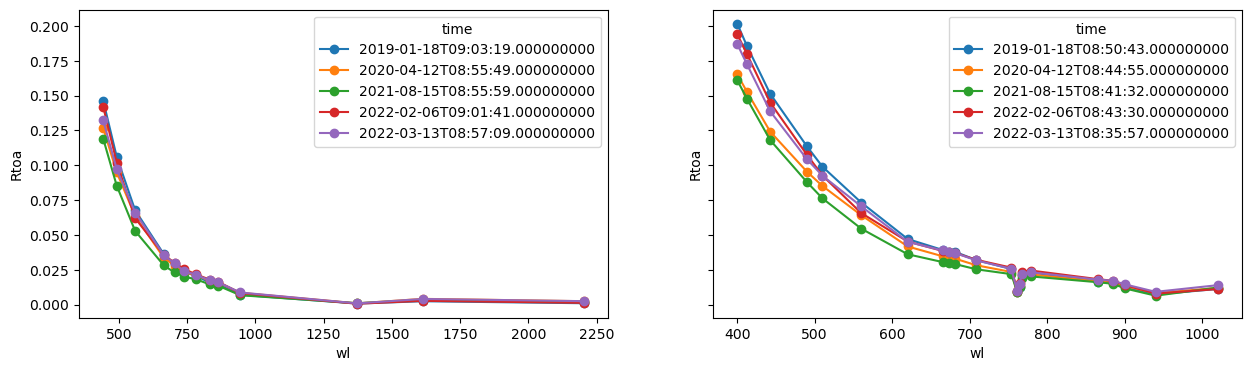

In [9]:
fig, axs = plt.subplots(1,2, sharey=True,figsize=(15, 4))
s2_arr.Rtoa.plot(hue='time',marker='o',ax=axs[0])
s3_arr.Rtoa.plot(hue='time',marker='o',ax=axs[1])


2019-01-18T09:03:19.000000000
2020-04-12T08:55:49.000000000
2021-08-15T08:55:59.000000000
2022-02-06T09:01:41.000000000
2022-03-13T08:57:09.000000000


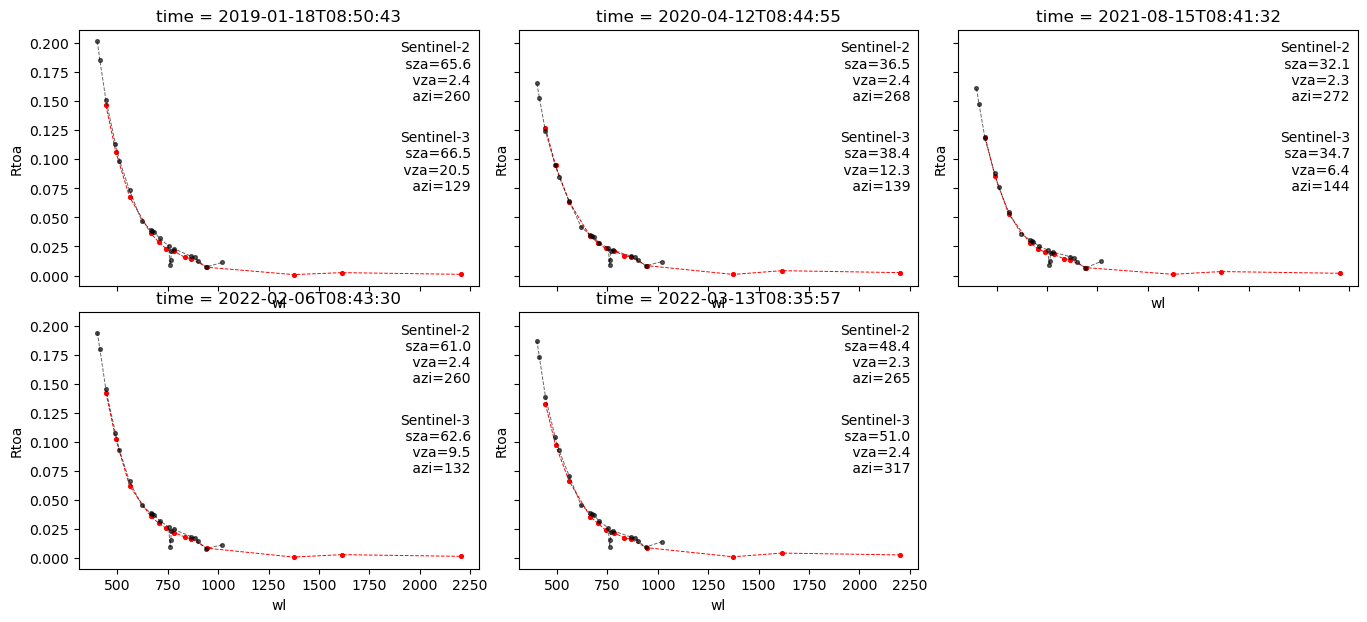

In [239]:
rows=2
cols=3
fig, axs = plt.subplots(nrows=rows,ncols=cols, sharex=True,figsize=(cols*5.5, rows*3.5),sharey=True)
fig.subplots_adjust(hspace=0.1,wspace=0.1)
axs_ = axs.ravel()
[axi.set_axis_off() for axi in axs_]
for ii,(date,ds2) in enumerate(s2_arr.groupby('time')):
    ax=axs_[ii]
    print(date)
    ds3 = s3_arr.sel(time=date,method='nearest')
    axs_[ii].set_axis_on()
    ds2.Rtoa.plot(c='red',marker='o',ms=2.7,ls='--',lw=0.7,ax=axs_[ii])
    ds3.Rtoa.plot(c='black',alpha=0.6,marker='o',ms=2.7,ls='--',lw=0.7,ax=axs_[ii])
    
    s2_text='Sentinel-2\n sza={:.1f}\n vza={:.1f}\n azi={:.0f}\n'.format(ds2.SZA.values,ds2.VZA.values,ds2.azi.values)
    s3_text='Sentinel-3\n sza={:.1f}\n vza={:.1f}\n azi={:.0f}\n'.format(ds3.SZA.values,ds3.VZA.values,ds3.azi.values)
    ax.text(0.98, 0.65,s2_text, verticalalignment='bottom', horizontalalignment='right',
                    transform=ax.transAxes)
    ax.text(0.98, 0.3,s3_text, verticalalignment='bottom', horizontalalignment='right',
                    transform=ax.transAxes)

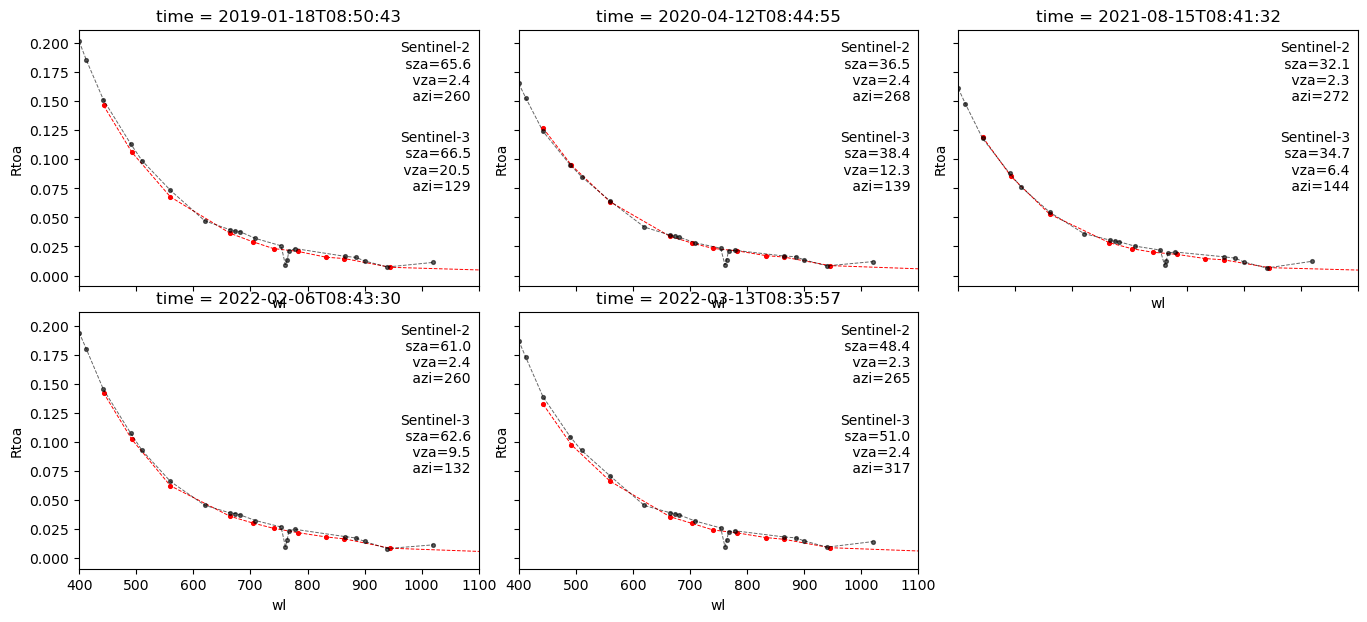

In [240]:

axs_[0].set_xlim(400,1100)
fig

In [10]:


import datetime
from aeronet_visu import data_loading as dl

opj = os.path.join

def get_month(imonth):
    return dt.datetime.date(1900, imonth, 1).strftime('%B')

sites = ['Abu_Al_Bukhoosh', 'ARIAKE_TOWER', 'Bahia_Blanca', 'Banana_River', 'Bari_Waterfront', 'Blyth_NOAH',
         'Casablanca_Platform', 'Chesapeake_Bay', 'COVE_SEAPRISM', 'Gageocho_Station', 'Galata_Platform', 'Gloria',
         'Gotland', 'GOT_Seaprism', 'Grizzly_Bay', 'Gustav_Dalen_Tower', 'HBOI', 'Helsinki_Lighthouse', 'Ieodo_Station',
         'Irbe_Lighthouse', 'KAUST_Campus', 'Kemigawa_Offshore', 'Lake_Erie', 'Lake_Okeechobee', 'Lake_Okeechobee_N',
         'LISCO', 'Lucinda', 'MVCO', 'Palgrunden', 'PLOCAN_Tower', 'Sacramento_River', 'San_Marco_Platform',
         'Section-7_Platform', 'Socheongcho', 'South_Greenbay', 'Thornton_C-power', 'USC_SEAPRISM', 'USC_SEAPRISM_2',
         'Venise', 'WaveCIS_Site_CSI_6', 'Zeebrugge-MOW1']


dir = '/DATA/AERONET/OCv3/'
figdir= '/DATA/AERONET/fig'
aeronet_site = 'Galata_Platform'
file = aeronet_site+'_OCv3.lev15'


irr = dl.irradiance()
irr.load_F0()

param = 'Lwn'

# ---------------------------------------------
# Load data and convert into xarray
# ---------------------------------------------

df = dl.read(opj(dir, file)).read_aeronet_ocv3()

df = df.droplevel(0, 1)
# criteria to select scalar and spectrum values
criteria = df.columns.get_level_values(1) == ''
df_att = df.loc[:, criteria].droplevel(1, 1)
df_spec = df.loc[:, ~criteria]

ds = df_spec.stack().to_xarray()
ds = xr.merge([ds, df_att.to_xarray()])
del df

ds = ds.assign_coords({'level_1': ds.level_1.astype(float)}).rename({'level_1': "wl"})
ds['SZA'] = ds.Solar_Zenith_Angle.mean(axis=1)
ds['year']=ds['date.year']
ds['season']=ds['date.season']

wl_ = ds.wavelength * 1000
ds['Rrs'] = ds[param] / (irr.get_F0(wl_) * 0.1)


/home/harmel/anaconda3/envs/grstbx/lib/python3.9/site-packages/aeronet_visu-1.0.0-py3.9.egg/aeronet_visu/data_loading.py:30: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df = pd.read_csv(ifile, skiprows=skiprows, na_values=['N/A', -999.0,-9.999999 ], parse_dates={'date': [1, 2]},


In [11]:
aeronet=ds.sel(date=s2_arr.time,method='nearest')
aeronet=aeronet.sortby(['time','wl']).squeeze()
aeronet

<xarray.Dataset>
Dimensions:                       (time: 5, wl: 14)
Coordinates:
    date                          (time) datetime64[ns] 2019-01-18T09:03:26 ....
  * wl                            (wl) float64 400.0 412.0 ... 870.0 1.02e+03
  * time                          (time) datetime64[ns] 2019-01-18T09:03:19 ....
Data variables: (12/42)
    Aerosol_Optical_Depth         (time, wl) float64 0.05486 0.05102 ... 0.04281
    wavelength                    (time, wl) float64 0.4 0.4129 ... nan 1.02
    Li_mean                       (time, wl) float64 4.716 5.158 ... nan 0.2988
    Li_stddev                     (time, wl) float64 0.004762 ... 0.000368
    Lt_mean                       (time, wl) float64 0.214 0.2498 ... 0.01022
    Lt_min_rel                    (time, wl) float64 0.1945 0.228 ... 0.008505
    ...                            ...
    ZSea(Degrees)                 (time) float64 40.0 40.0 40.0 40.0 40.0
    site                          (time) object 'Galata_Platform' ... 'Galata...
    SZA                           (time) float64 65.74 37.78 33.27 61.32 49.19
    year                          (time) int64 2019 2020 2021 2022 2022
    season                        (time) object 'DJF' 'MAM' 'JJA' 'DJF' 'MAM'
    Rrs                           (time, wl) float64 0.001225 ... 1.019e-05

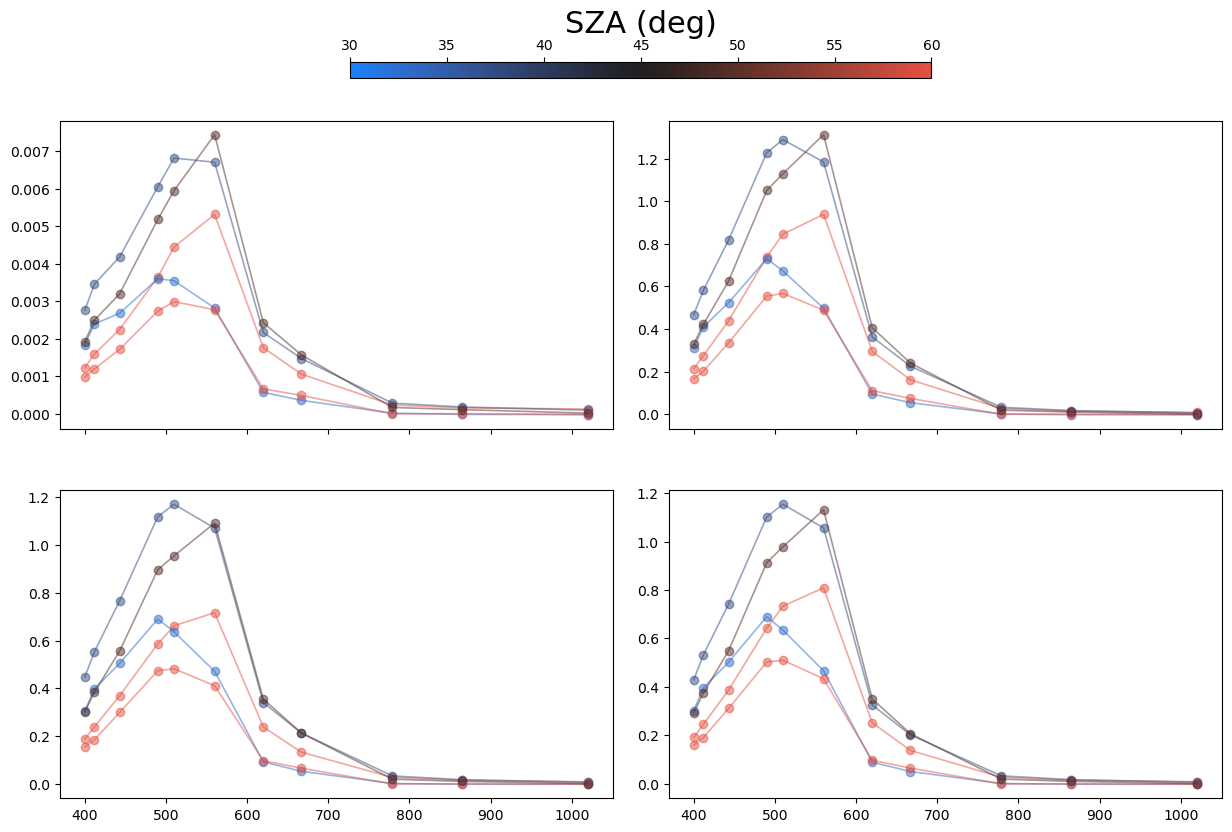

In [12]:
cols=2
rows=2 #len(np.unique(ds['date.year']))
fpdf=[]
cparam='SZA'
cmap = cc.cm.bkr
norm = mpl.colors.Normalize(vmin=30, vmax=60)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

fig, axs = plt.subplots(nrows=rows,ncols=cols, sharex=True,figsize=(15, rows*5.5))
fig.subplots_adjust(hspace=0.2,wspace=0.1)
axs=axs.ravel()
for date,aeronet_ in aeronet.groupby('time'):
    _=aeronet_.dropna('wl')
    axs[0].plot(_.wl,_.Rrs,color=cmap(norm(_[cparam])), marker='o', lw=1.2,alpha=0.5)#,cmap=cc.cm.bgyw)
    axs[1].plot(_.wl,_.Lwn,color=cmap(norm(_[cparam])), marker='o', lw=1.2,alpha=0.5)#,cmap=cc.cm.bgyw)
    axs[2].plot(_.wl,_['Lwn_f/Q'],color=cmap(norm(_[cparam])), marker='o', lw=1.2,alpha=0.5)#,cmap=cc.cm.bgyw)
    axs[3].plot(_.wl,_.Lwn_IOP,color=cmap(norm(_[cparam])), marker='o', lw=1.2,alpha=0.5)#,cmap=cc.cm.bgyw)


cb = fig.colorbar(sm, ax=axs, shrink=0.5, aspect=35, pad=0.05, location='top')
cb.set_label('SZA (deg)', fontsize=22)


plt.show()

In [14]:
Ttot_Ed=xr.open_dataset('/DATA/git/satellite_app/hgrs/data/lut/transmittance_downward_irradiance.nc')
Ttot_Ed

<xarray.Dataset>
Dimensions:  (wl: 10, aot_ref: 9, sza: 9, model: 8)
Coordinates:
  * wl       (wl) float32 350.0 400.0 500.0 600.0 ... 1.6e+03 2.2e+03 2.5e+03
  * aot_ref  (aot_ref) float32 0.001 0.01 0.1 0.2 0.35 0.5 0.7 1.0 1.5
  * sza      (sza) float32 0.0 10.0 20.0 30.0 40.0 50.0 60.0 70.0 80.0
  * model    (model) object 'COAV_rh70' 'DESE_rh70' ... 'ARCT_rh70' 'ANTA_rh70'
Data variables:
    Ttot_Ed  (model, aot_ref, wl, sza) float32 ...

In [34]:
aot550

array(0.1168422)

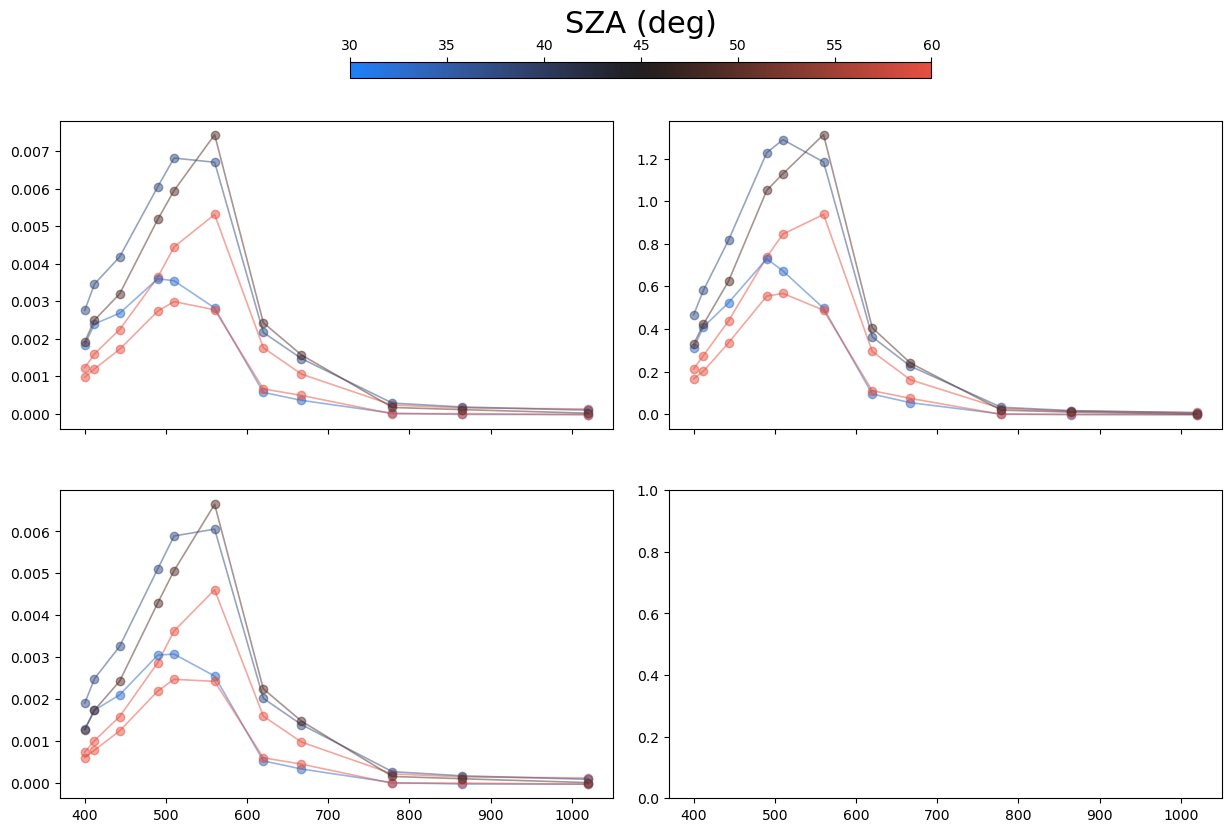

In [39]:
model='COAV_rh70'    
aot550=0.01
cols=2
rows=2 #len(np.unique(ds['date.year']))
fpdf=[]
cparam='SZA'
cmap = cc.cm.bkr
norm = mpl.colors.Normalize(vmin=30, vmax=60)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
vza=4
fig, axs = plt.subplots(nrows=rows,ncols=cols, sharex=True,figsize=(15, rows*5.5))
fig.subplots_adjust(hspace=0.2,wspace=0.1)

for date,aeronet_ in aeronet.groupby('time'):
    _=aeronet_.dropna('wl')
    axs[0,0].plot(_.wl,_.Rrs,color=cmap(norm(_[cparam])), marker='o', lw=1.2,alpha=0.5)#,cmap=cc.cm.bgyw)
    axs[0,1].plot(_.wl,_.Lwn,color=cmap(norm(_[cparam])), marker='o', lw=1.2,alpha=0.5)#,cmap=cc.cm.bgyw)
    sza = _.SZA.values
    aot550 = _.Aerosol_Optical_Depth.interp(wl=550).values
    Ttot_Ed_ = Ttot_Ed.Ttot_Ed.sel(model=model).interp(sza=sza, method='cubic').interp(aot_ref=aot550, method='quadratic').interp(wl=_.wl, method='cubic')
    Ttot_Lu_ = Ttot_Ed.Ttot_Ed.sel(model=model).interp(sza=vza, method='cubic').interp(aot_ref=aot550, method='quadratic').interp(wl=_.wl, method='cubic')**1.05
    
    
    Rtoa_w= Ttot_Ed_*Ttot_Lu_*_.Rrs
    axs[1,0].plot(_.wl,Rtoa_w,color=cmap(norm(_[cparam])), marker='o', lw=1.2,alpha=0.5)#,cmap=cc.cm.bgyw)


cb = fig.colorbar(sm, ax=axs, shrink=0.5, aspect=35, pad=0.05, location='top')
cb.set_label('SZA (deg)', fontsize=22)


plt.show()

In [40]:
Rtoa_w.interp(wl=wl,kwargs={"fill_value":0})

<xarray.DataArray (wl: 1000)>
array([1.27665820e-03, 1.35762051e-03, 1.43858283e-03, 1.51954514e-03,
       1.60050746e-03, 1.68146978e-03, 1.75250949e-03, 1.79942368e-03,
       1.84633787e-03, 1.89325206e-03, 1.94016625e-03, 1.98708044e-03,
       2.03399463e-03, 2.08090882e-03, 2.12782301e-03, 2.17473720e-03,
       2.22165139e-03, 2.26856558e-03, 2.31547976e-03, 2.36239395e-03,
       2.40930814e-03, 2.47615102e-03, 2.55967961e-03, 2.64320819e-03,
       2.72673678e-03, 2.81026536e-03, 2.89379395e-03, 2.97732253e-03,
       3.06085112e-03, 3.14437970e-03, 3.22790829e-03, 3.31143687e-03,
       3.39496546e-03, 3.47849404e-03, 3.56202263e-03, 3.64555121e-03,
       3.72907980e-03, 3.81260838e-03, 3.89613697e-03, 3.97966555e-03,
       4.06319414e-03, 4.14672272e-03, 4.23025131e-03, 4.31320982e-03,
       4.39366882e-03, 4.47412781e-03, 4.55458680e-03, 4.63504579e-03,
       4.71550478e-03, 4.79596378e-03, 4.87642277e-03, 4.95688176e-03,
       5.03734075e-03, 5.10852549e-03, 5.17517177e-03, 5.24181805e-03,
       5.30846433e-03, 5.37511061e-03, 5.44175689e-03, 5.50840317e-03,
       5.57504945e-03, 5.64169573e-03, 5.70834201e-03, 5.77498829e-03,
       5.84163457e-03, 5.90828084e-03, 5.97492712e-03, 6.04157340e-03,
       6.10821968e-03, 6.17486596e-03, 6.24151224e-03, 6.30815852e-03,
       6.37480480e-03, 6.44145108e-03, 6.50809736e-03, 6.57474364e-03,
       6.64138992e-03, 6.51236930e-03, 6.35810133e-03, 6.20383337e-03,
...
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00])
Coordinates:
    model    <U9 'COAV_rh70'
    aot_ref  float64 0.01
    date     datetime64[ns] 2022-03-13T08:56:55
    time     datetime64[ns] 2022-03-13T08:57:09
  * wl       (wl) float64 400.0 402.1 404.2 ... 2.496e+03 2.498e+03 2.5e+03

In [41]:
sza=65
vza=4
raa=90
wl=np.linspace(400,2500,1000)
wl_glint=2200
brdfg_ref=0.1
tcwv=5
to3c=6.5e-3
tno2c=3e-6
tch4c= 1e-2
pressure=1000

In [42]:
lut_file = '/DATA/git/satellite_app/hgrs/data/lut/opac_osoaa_lut_v3.nc'
aero_lut = xr.open_dataset(lut_file)
aero_lut['wl']=aero_lut['wl']*1000

aero_lut=aero_lut.isel(z=-1).squeeze()

In [43]:
abs_file = '/DATA/git/vrtc/libradtran_tbx/output/lut_abs_opt_thickness_normalized.nc' 
ot =xr.open_dataset(abs_file)


## Convert OT for actual gas content (in kg/m2) and pressure (in hPa)

In [44]:
def get_pressure(alt, psl):
    '''Compute the pressure for a given altitude
       alt : altitude in meters (float or np.array)
       psl : pressure at sea level in hPa
       palt : pressure at the given altitude in hPa'''

    palt = psl * (1. - 0.0065 * np.nan_to_num(alt) / 288.15) ** 5.255
    return palt
psl=1010
alt=0
get_pressure(alt, psl)

1010.0

In [45]:


#['ch4','co','co2','h2o','n2o','no2','o2','o3','o4']
M=1./np.cos(np.radians(sza))+1./np.cos(np.radians(vza))
ot_wv = ot.h2o *tcwv
ot_o3 = ot.o3 * to3c
ot_ch4 = ot.ch4 * tch4c
ot_no2 = ot.no2 * tno2c
ot_others = (ot.co+ot.co2+ot.n2o+ot.o2+ot.o4)* pressure/1000

ot_tot = ot_wv+ot_ch4+ot_no2+ot_o3+ot_others 

Ttot = np.exp(-M*ot_tot)
Ttot_coarsened = Ttot.coarsen(wl=110,boundary= "trim").mean()
Tabs = Ttot_coarsened.interp(wl=wl,method='cubic')
    

In [46]:

azi=180-raa
def transmittance_dir(aot,M,rot=0):    
    return np.exp(-(rot+aot)*M)


auxdata = hgrs.auxdata()#wl=masked.wl)

sunglint_eps = auxdata.sunglint_eps['mean'].interp(wl=wl)
sunglint_corr = sunglint_eps / sunglint_eps.sel(wl=wl_glint,method='nearest')
rot = auxdata.rot.interp(wl=wl)


In [47]:
cmap = mpl.colors.LinearSegmentedColormap.from_list("",
                                                    ['navy', "blue", 'lightskyblue',
                                                     "grey",   'forestgreen','yellowgreen',
                                                     "khaki", "gold",
                                                     'orangered', "firebrick", 'purple'])

norm = mpl.colors.Normalize(vmin=0.001,vmax=1.1)#-3, vmax=np.log10(1.5))

models = ['COAV', 'COPO', 'DESE', 'MACL', 'MAPO', 'URBA']
rh='_rh70'

(400.0, 1100.0)

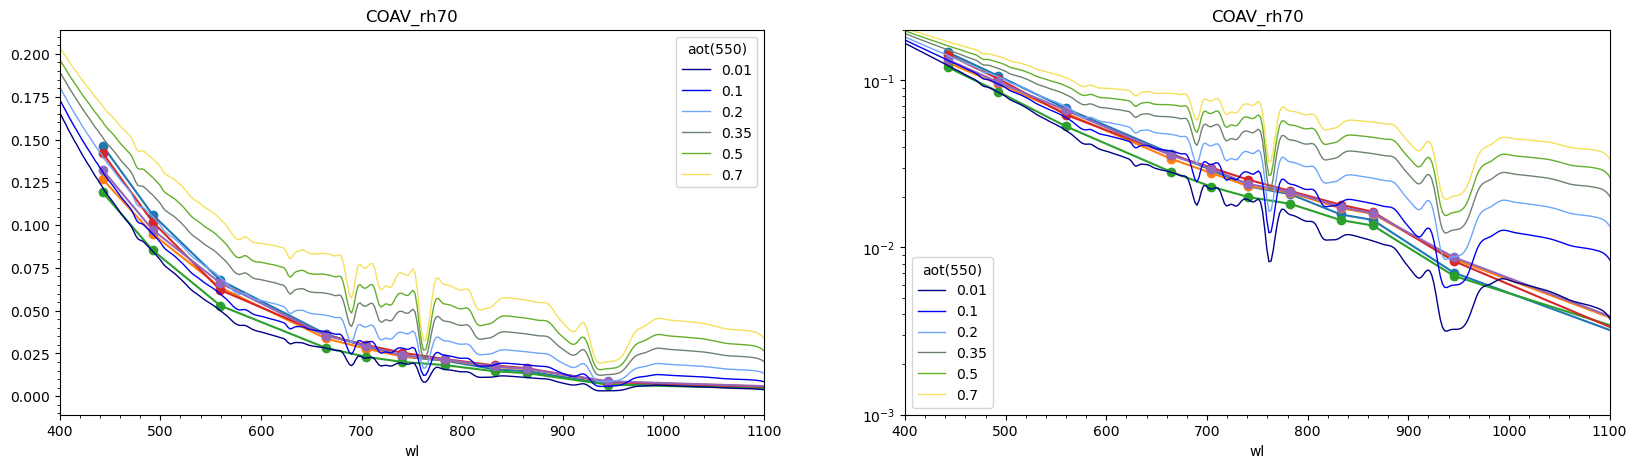

In [48]:
brdfg_ref=0
fig,axs = plt.subplots(1,2,figsize=(20,5),sharex=True)
axs=axs.ravel()
model='COAV_rh70'    

Rtoa_lut = aero_lut.I.sel(model=model,aot_ref=slice(0.,0.74)).sel(sza=sza,vza=vza,azi=azi,method='nearest').squeeze()/np.cos(np.radians(sza))

Rtoa_lut=Rtoa_lut.interp(wl=wl,method='cubic')

aot=aero_lut.sel(model=model).aot.interp(wl=wl,method='cubic')
Tdir = transmittance_dir(aot,M,rot=rot)
sunglint_corr = Tdir * sunglint_eps
sunglint_toa=sunglint_corr *brdfg_ref#( pixel.sel(wl=slice(2150,2350))-Rtoa_lut.sel(wl=slice(2150,2350))).mean(dim='wl')
#sunglint_toa.Rtoa.plot(x='wl',hue='aot_ref',ax=axs[0])

Rsim = Tabs*( sunglint_toa+Rtoa_lut)
for i_ in [0,1]:
    s2_arr.Rtoa.plot(hue='time',marker='o',ax=axs[i_])
    for aot_ref in Rtoa_lut.aot_ref.values[1:]:
        #Rtoa_lut.sel(aot_ref=aot_ref).plot(x='wl',color=cmap(norm(aot_ref)),ls=':',lw=1,ax=axs[i_])
        Rsim.sel(aot_ref=aot_ref).plot(x='wl',color=cmap(norm(aot_ref)),label=str(aot_ref),lw=1,ax=axs[i_])
    #Rtoa_sim= Rsim.interp(aot_ref=0.4)
    #Rtoa_sim.plot(x='wl',color='black',ls='--',ax=axs[i_])
    axs[i_].set_title(model)
    axs[i_].minorticks_on()
    axs[i_].legend(title='aot(550)')
axs[1].semilogy()
axs[1].set_ylim(1e-3,0.2)

axs[1].set_xlim(400,1100)

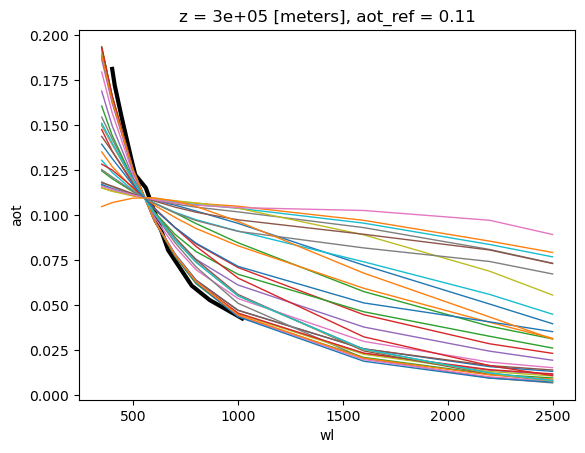

In [49]:

aot550=0.11
aeronet_=aeronet.sel(time=date,method='nearest').dropna('wl')
aeronet_.Aerosol_Optical_Depth.plot(color='black',lw=3)
#(aero_lut.ssa.interp(aot_ref=aot550)*aero_lut.aot.interp(aot_ref=aot550)).plot(x='wl',hue='model',lw=1,add_legend=False)
(aero_lut.aot.interp(aot_ref=aot550)).plot(x='wl',hue='model',lw=1,add_legend=False)

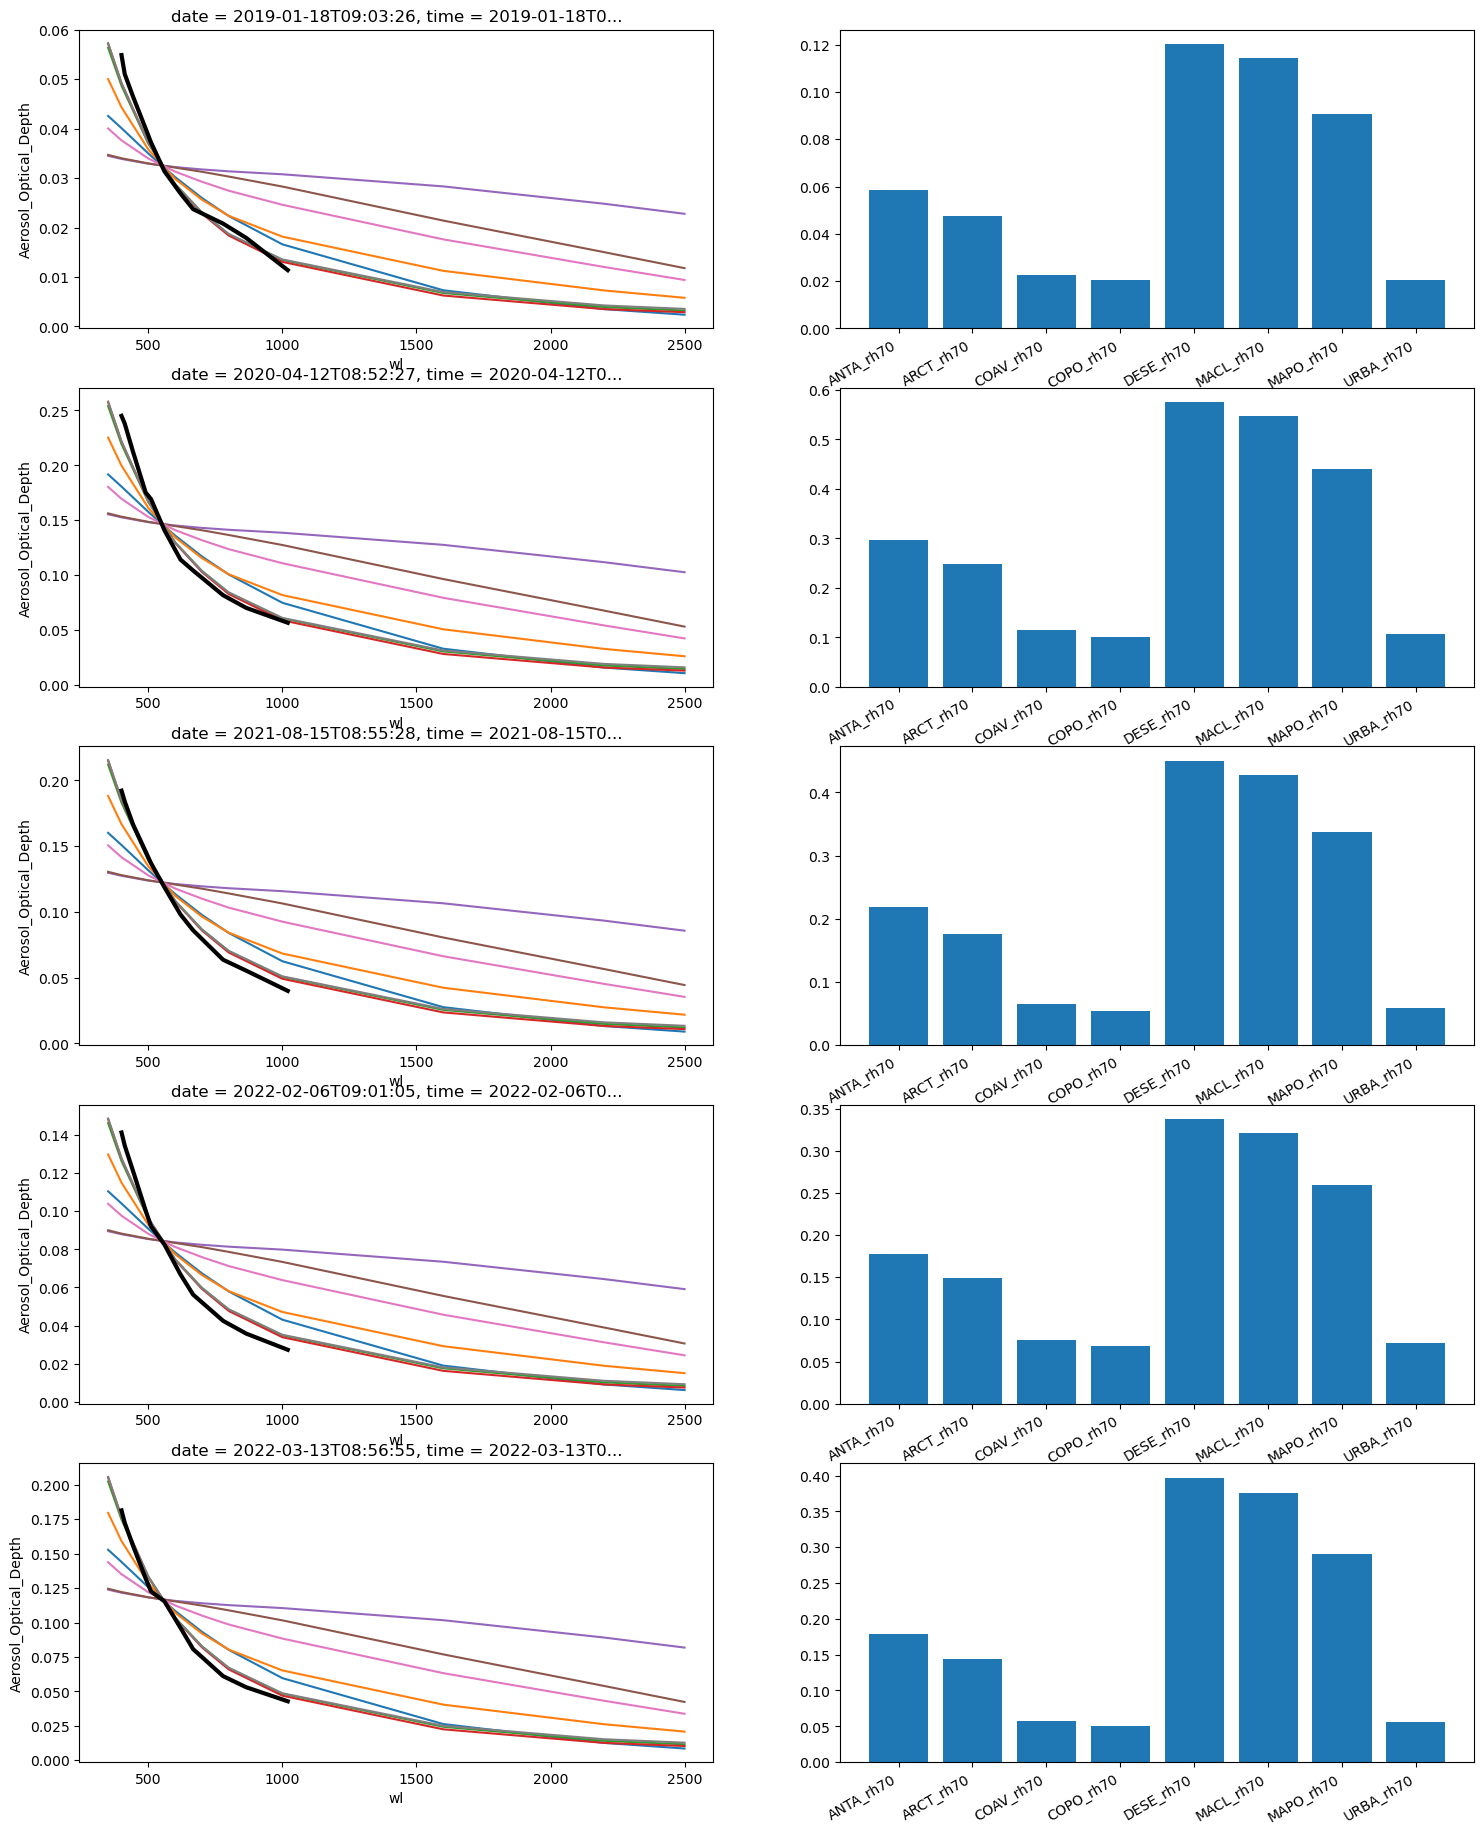

<xarray.Dataset>
Dimensions:            (wl: 10, model: 32, aot_ref: 9, sza: 9, vza: 61, azi: 73)
Coordinates:
  * wl                 (wl) float32 350.0 400.0 500.0 ... 2.2e+03 2.5e+03
  * aot_ref            (aot_ref) float32 0.001 0.01 0.1 0.2 0.35 0.5 0.7 1.0 1.5
    z                  float32 3e+05
  * sza                (sza) float32 0.0 10.0 20.0 30.0 40.0 50.0 60.0 70.0 80.0
  * vza                (vza) float32 0.0 1.14 2.62 4.11 ... 86.27 87.76 89.25
  * azi                (azi) float32 0.0 5.0 10.0 15.0 ... 350.0 355.0 360.0
  * model              (model) object 'COAV_rh0' 'DESE_rh0' ... 'ANTA_rh99'
Data variables: (12/20)
    wl_ref             (model, wl, aot_ref) float32 ...
    Cext_ref           (model, wl, aot_ref) float32 ...
    ssa_ref            (model, wl, aot_ref) float32 ...
    aot                (model, wl, aot_ref) float32 ...
    Cext               (model, wl, aot_ref) float32 ...
    ssa                (model, wl, aot_ref) float32 ...
    ...                 ...
    Eddir              (model, aot_ref, wl, sza) float32 ...
    Eudir              (model, aot_ref, wl, sza) float32 ...
    Eodir              (model, aot_ref, wl, sza) float32 ...
    I                  (model, wl, aot_ref, sza, vza, azi) float32 ...
    Q                  (model, wl, aot_ref, sza, vza, azi) float32 ...
    U                  (model, wl, aot_ref, sza, vza, azi) float32 ...

In [28]:

models=aero_lut.model.values
rh='_rh70'
models = ['ANTA'+rh,'ARCT'+rh,'COAV'+rh, 'COPO'+rh, 'DESE'+rh, 'MACL'+rh, 'MAPO'+rh, 'URBA'+rh]

fig, axs = plt.subplots(5, 2, figsize=(18, 5*4.5))
for ii,(time,aeronet_) in  enumerate(aeronet.groupby('time')):
    aeronet_=aeronet_.dropna('wl')
    aot550=aeronet_.Aerosol_Optical_Depth.interp(wl=550).values
    aero_lut.aot.sel(model=models).interp(aot_ref=aot550).plot(ax=axs[ii,0],hue='model',add_legend=False)

    aeronet_.Aerosol_Optical_Depth.plot(color='black',lw=3,ax=axs[ii,0])

    lut_aod=aero_lut.aot.sel(model=models).interp(aot_ref=aot550).interp(wl=aeronet_.wl)
    rank = np.abs(aeronet_.Aerosol_Optical_Depth-lut_aod).sum('wl') 
    axs[ii,1].bar(x=rank.model, height=rank.values)
    plt.setp(axs[ii,1].get_xticklabels(), rotation=30, ha="right")

    #ax.tick_params(axis='x', rotation=30)#, ha='right')
plt.show()

aero_lut


In [50]:
brdfg_ref=0.
aeronet_['Pressure(hPa)']
model

'COAV_rh70'

In [51]:
ds3

<xarray.Dataset>
Dimensions:                (wl: 21)
Coordinates:
    time                   datetime64[ns] 2019-01-18T08:50:43
  * wl                     (wl) float64 400.0 412.5 442.5 ... 940.0 1.02e+03
Data variables:
    Rtoa                   (wl) float64 0.2016 0.1856 ... 0.007348 0.01127
    Aeronet OC Acq. Time   object '20190118T085838'
    Product name           object 'S3A_OL_1_EFR____20190118T085043_20190118T0...
    SZA                    float64 66.49
    VZA                    float64 20.53
    Phis                   float64 158.4
    Phiv                   float64 -73.06
    PHIV+360               float64 286.9
    PHIV-PHIV              float64 128.5
    azi                    float64 128.5

2019-01-18T09:03:19.000000000
2020-04-12T08:55:49.000000000
2021-08-15T08:55:59.000000000
2022-02-06T09:01:41.000000000
2022-03-13T08:57:09.000000000


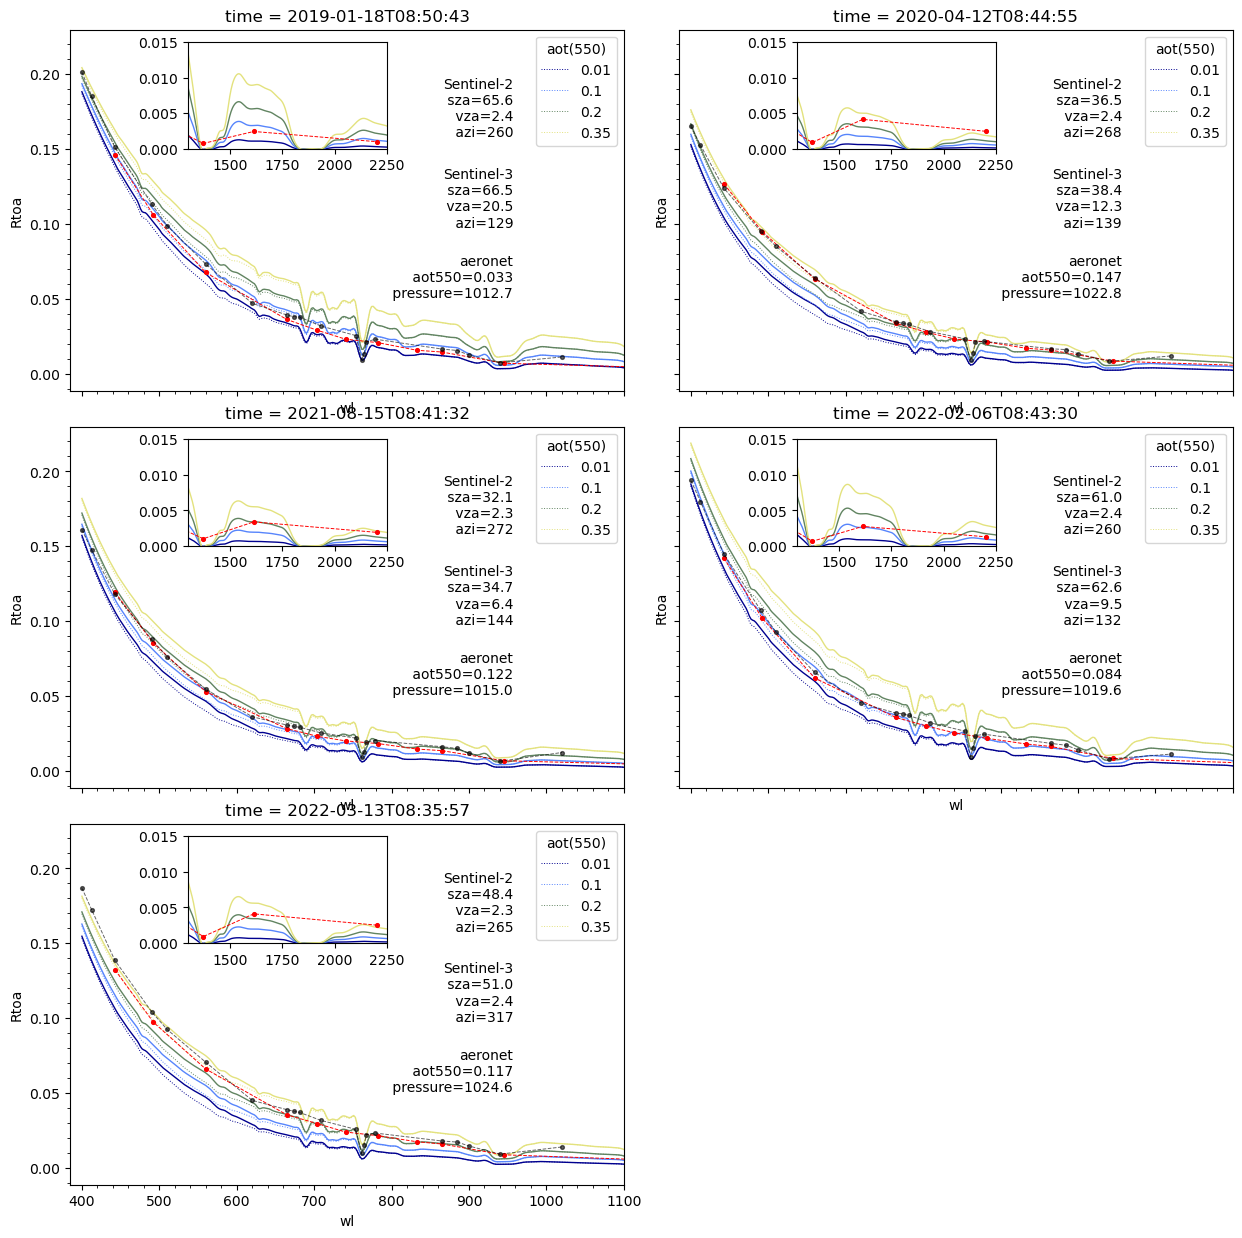

In [52]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

rows=3
cols=2
model='MACL_rh70'
model='COPO_rh70'
to3c=1.5e-3
tno2c=0.5e-6

norm = mpl.colors.Normalize(vmin=0.001,vmax=0.6)
fig, axs = plt.subplots(nrows=rows,ncols=cols, sharex=True,figsize=(cols*7.5, rows*5),sharey=True)
fig.subplots_adjust(hspace=0.1,wspace=0.1)
axs_ = axs.ravel()
[axi.set_axis_off() for axi in axs_]
for ii,(date,ds2) in enumerate(s2_arr.groupby('time')):
    print(date)
    ds3 = s3_arr.sel(time=date,method='nearest')
    aziRT=(180-ds3.azi.values)%360
    aziRT=ds3.azi.values
    aeronet_=aeronet.sel(time=date,method='nearest').dropna('wl')
    aot550 = aeronet_.Aerosol_Optical_Depth.interp(wl=550)
    pressure = aeronet_['Pressure(hPa)'].values
    
    
    sza=np.mean([ds2.SZA.values,ds3.SZA.values])
    vza=np.mean([ds2.VZA.values,ds3.VZA.values])
    M=1./np.cos(np.radians(sza))+1./np.cos(np.radians(vza))
    
    # diffuse light simu
    Rtoa_lut = aero_lut.I.sel(model=model,aot_ref=slice(0.,0.4)).sel(sza=sza,vza=vza,azi=aziRT,method='nearest').squeeze()/np.cos(np.radians(sza))
    Rtoa_lut=Rtoa_lut.interp(wl=wl,method='cubic')

    # sunglint simu
    aot=aero_lut.sel(model=model).aot.interp(wl=wl,method='cubic')
    Tdir = transmittance_dir(aot,M,rot=rot)
    sunglint_corr = Tdir * sunglint_eps
    sunglint_toa=sunglint_corr *brdfg_ref#( pixel.sel(wl=slice(2150,2350))-Rtoa_lut.sel(wl=slice(2150,2350))).mean(dim='wl')
    #sunglint_toa.Rtoa.plot(x='wl',hue='aot_ref',ax=axs[0])   

    # absorbing gas transmittance
    ot_wv = ot.h2o *tcwv
    ot_o3 = ot.o3 * to3c
    ot_ch4 = ot.ch4 * tch4c
    ot_no2 = ot.no2 * tno2c
    ot_others = (ot.co+ot.co2+ot.n2o+ot.o2+ot.o4)* pressure/1000

    ot_tot = ot_wv+ot_ch4+ot_no2+ot_o3+ot_others 

    Ttot = np.exp(-M*ot_tot)
    Ttot_coarsened = Ttot.coarsen(wl=110,boundary= "trim").mean()
    Tabs = Ttot_coarsened.interp(wl=wl,method='cubic')
    
    # Top-of-atmosphere simu
    Rsim = Tabs*( sunglint_toa+Rtoa_lut)
    Rsim2=Tabs*( sunglint_toa+Rtoa_lut+Rtoa_w.interp(wl=wl,kwargs={"fill_value":0}))
        
    ax=axs_[ii]
    ax.set_axis_on()
    ax.minorticks_on()
    axins = inset_axes(ax, width="40%", height="33%",
                   bbox_to_anchor=(.2, .65, 0.9, 0.9),
                   bbox_transform=ax.transAxes, loc=3)
   
    for aot_ref in Rtoa_lut.aot_ref.values[1:]:
        #Rtoa_lut.sel(aot_ref=aot_ref).plot(x='wl',color=cmap(norm(aot_ref)),ls=':',lw=1,ax=axs[i_])
        Rsim.sel(aot_ref=aot_ref).plot(x='wl',ls=':',color=cmap(norm(aot_ref)),label=str(aot_ref),lw=0.7,ax=ax)
        Rsim.sel(aot_ref=aot_ref).plot(x='wl',color=cmap(norm(aot_ref)),label=str(aot_ref),lw=1,ax=axins)
        Rsim2.sel(aot_ref=aot_ref).plot(x='wl',color=cmap(norm(aot_ref)),lw=1,ax=ax)
    ds2.Rtoa.plot(c='red',marker='o',ms=2.7,ls='--',lw=.7,ax=ax)
    ds2.Rtoa.plot(c='red',marker='o',ms=2.7,ls='--',lw=.7,ax=axins)
    ds3.Rtoa.plot(c='black',alpha=0.6,marker='o',ms=2.7,ls='--',lw=0.7,ax=ax)
    
    axins.set_title('')
    axins.set_xlabel('')
    axins.set_ylabel('')
    axins.set_xlim(1300,2250)
    axins.set_ylim(0,0.015)
    
    ax.set_xlim(385,1100)
    
    s2_text='Sentinel-2\n sza={:.1f}\n vza={:.1f}\n azi={:.0f}\n'.format(ds2.SZA.values,ds2.VZA.values,ds2.azi.values)
    s3_text='Sentinel-3\n sza={:.1f}\n vza={:.1f}\n azi={:.0f}\n'.format(ds3.SZA.values,ds3.VZA.values,ds3.azi.values)
    ax.text(0.8, 0.65,s2_text, verticalalignment='bottom', horizontalalignment='right',
                    transform=ax.transAxes)
    ax.text(0.8, 0.4,s3_text, verticalalignment='bottom', horizontalalignment='right',
                    transform=ax.transAxes)
    ax.text(0.8, 0.25, 'aeronet\n aot550={:.3f}\n pressure={:.1f}'.format(aot550,pressure), verticalalignment='bottom', horizontalalignment='right',
                    transform=ax.transAxes)
    ax.legend(title='aot(550)')

2019-01-18T09:03:19.000000000
2020-04-12T08:55:49.000000000
2021-08-15T08:55:59.000000000
2022-02-06T09:01:41.000000000
2022-03-13T08:57:09.000000000


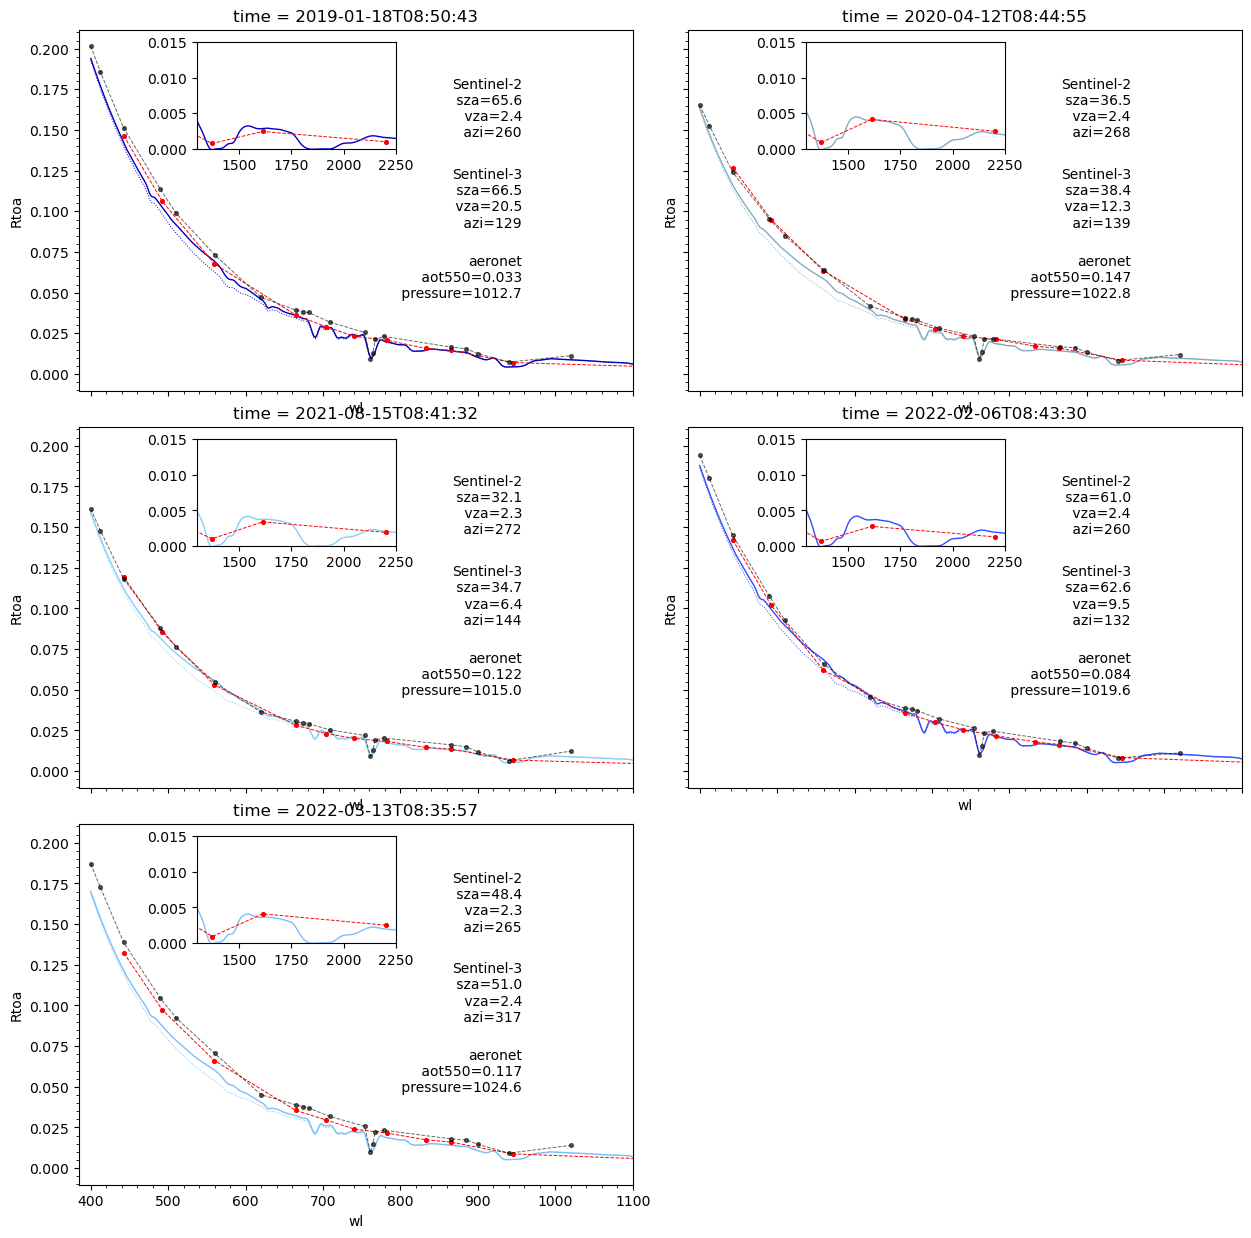

In [80]:

rows=3
cols=2
model='MACL_rh70'
model='COAV_rh0'
to3c=4.5e-3
tno2c=0.5e-6
brdfg_ref=0.001
norm = mpl.colors.Normalize(vmin=0.001,vmax=0.6)
fig, axs = plt.subplots(nrows=rows,ncols=cols, sharex=True,figsize=(cols*7.5, rows*5),sharey=True)
fig.subplots_adjust(hspace=0.1,wspace=0.1)
axs_ = axs.ravel()
[axi.set_axis_off() for axi in axs_]
for ii,(date,ds2) in enumerate(s2_arr.groupby('time')):
    print(date)
    ds3 = s3_arr.sel(time=date,method='nearest')
    aziRT=(180-ds2.azi.values)%360
    aziRT=ds2.azi.values
    aeronet_=aeronet.sel(time=date,method='nearest').dropna('wl')
    aot550 = 1.*aeronet_.Aerosol_Optical_Depth.interp(wl=550).values
    pressure = aeronet_['Pressure(hPa)'].values
    
    
    sza=ds2.SZA.values #np.mean([ds2.SZA.values,ds3.SZA.values])
    vza=ds2.VZA.values #np.mean([ds2.VZA.values,ds3.VZA.values])
    M=1./np.cos(np.radians(sza))+1./np.cos(np.radians(vza))
    
    # diffuse light simu
    Rtoa_lut = aero_lut.I.sel(model=model).sel(vza=vza,azi=aziRT,method='nearest').interp(aot_ref=aot550).interp(sza=sza,method='cubic').squeeze()/np.cos(np.radians(sza))
    Rtoa_lut=Rtoa_lut.interp(wl=wl,method='cubic')*pressure/1015

    # sunglint simu
    aot=aero_lut.sel(model=model).aot.interp(aot_ref=aot550).interp(wl=wl,method='cubic')
    Tdir = transmittance_dir(aot,M,rot=rot)
    sunglint_corr = Tdir * sunglint_eps
    sunglint_toa=sunglint_corr *brdfg_ref#( pixel.sel(wl=slice(2150,2350))-Rtoa_lut.sel(wl=slice(2150,2350))).mean(dim='wl')
    #sunglint_toa.Rtoa.plot(x='wl',hue='aot_ref',ax=axs[0])   

    # absorbing gas transmittance
    ot_wv = ot.h2o *tcwv
    ot_o3 = ot.o3 * to3c*0
    ot_ch4 = ot.ch4 * tch4c
    ot_no2 = ot.no2 * tno2c
    ot_others = (ot.co+ot.co2+ot.n2o+ot.o2+ot.o4)* pressure/1000

    ot_tot = ot_wv+ot_ch4+ot_no2+ot_o3+ot_others 

    Ttot = np.exp(-M*ot_tot)
    Ttot_coarsened = Ttot.coarsen(wl=110,boundary= "trim").mean()
    Tabs = Ttot_coarsened.interp(wl=wl,method='cubic')
    
    # Top-of-atmosphere simu
    Rsim = Tabs*( sunglint_toa+Rtoa_lut)
    Rsim2=Tabs*( sunglint_toa+Rtoa_lut+Rtoa_w.interp(wl=wl,kwargs={"fill_value":0}))#/np.cos(np.radians(sza)))
        
    ax=axs_[ii]
    ax.set_axis_on()
    ax.minorticks_on()
    axins = inset_axes(ax, width="40%", height="33%",
                   bbox_to_anchor=(.2, .65, 0.9, 0.9),
                   bbox_transform=ax.transAxes, loc=3)
   
    
    Rsim.plot(x='wl',color=cmap(norm(aot550)),label=str(aot_ref),ls=':',lw=0.7,ax=ax)
    Rsim.plot(x='wl',color=cmap(norm(aot550)),label=str(aot_ref),lw=1,ax=axins)
    Rsim2.plot(x='wl',color=cmap(norm(aot550)),lw=1,ax=ax)
    ds2.Rtoa.plot(c='red',marker='o',ms=2.7,ls='--',lw=0.7,ax=ax)
    ds2.Rtoa.plot(c='red',marker='o',ms=2.7,ls='--',lw=0.7,ax=axins)
    ds3.Rtoa.plot(c='black',alpha=0.6,marker='o',ms=2.7,ls='--',lw=0.7,ax=ax)
    
    axins.set_title('')
    axins.set_xlabel('')
    axins.set_ylabel('')
    axins.set_xlim(1300,2250)
    axins.set_ylim(0,0.015)
    
    ax.set_xlim(385,1100)
    
    s2_text='Sentinel-2\n sza={:.1f}\n vza={:.1f}\n azi={:.0f}\n'.format(ds2.SZA.values,ds2.VZA.values,ds2.azi.values)
    s3_text='Sentinel-3\n sza={:.1f}\n vza={:.1f}\n azi={:.0f}\n'.format(ds3.SZA.values,ds3.VZA.values,ds3.azi.values)
    ax.text(0.8, 0.65,s2_text, verticalalignment='bottom', horizontalalignment='right',
                    transform=ax.transAxes)
    ax.text(0.8, 0.4,s3_text, verticalalignment='bottom', horizontalalignment='right',
                    transform=ax.transAxes)
    ax.text(0.8, 0.25, 'aeronet\n aot550={:.3f}\n pressure={:.1f}'.format(aot550,pressure), verticalalignment='bottom', horizontalalignment='right',
                    transform=ax.transAxes)
    #ax.legend(title='aot(550)')

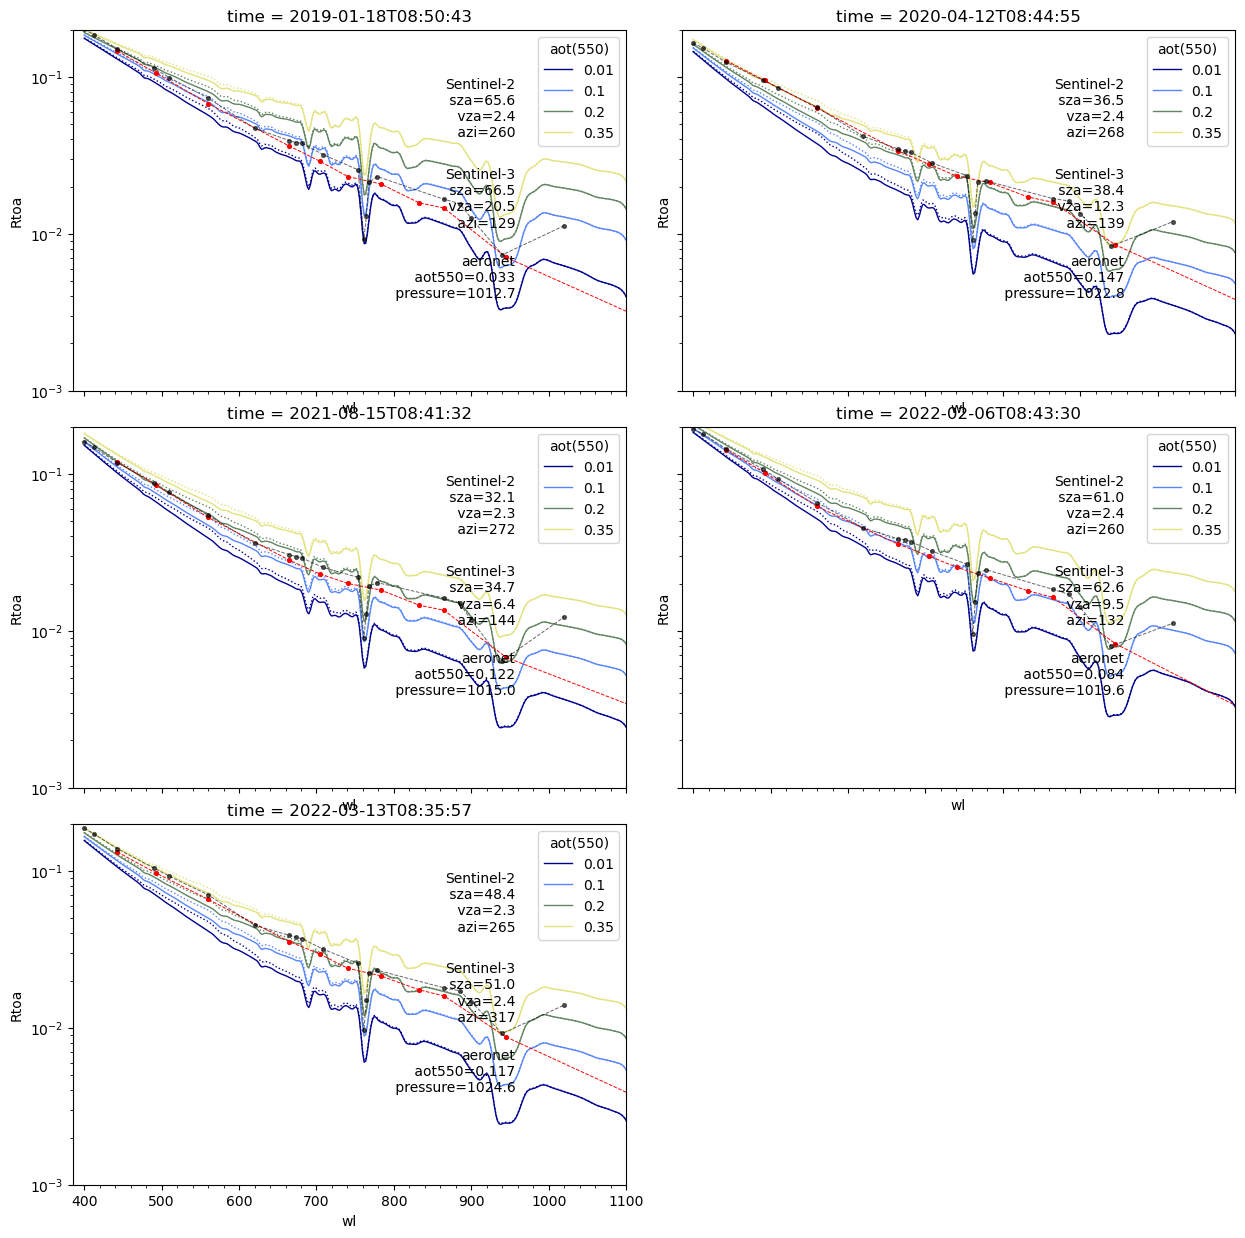

In [308]:
axs_[0].semilogy()
axs_[0].set_ylim(1e-3,0.2)
fig

In [63]:
ds2.wl

<xarray.DataArray 'wl' (wl: 13)>
array([ 442.7,  492.4,  559.8,  664.6,  704.1,  740.5,  782.8,  832.8,  864.7,
        945.1, 1373.5, 1613.7, 2202.4])
Coordinates:
    time     datetime64[ns] 2022-03-13T08:57:09
  * wl       (wl) float64 442.7 492.4 559.8 ... 1.374e+03 1.614e+03 2.202e+03

2019-01-18T09:03:19.000000000
2020-04-12T08:55:49.000000000
2021-08-15T08:55:59.000000000
2022-02-06T09:01:41.000000000
2022-03-13T08:57:09.000000000


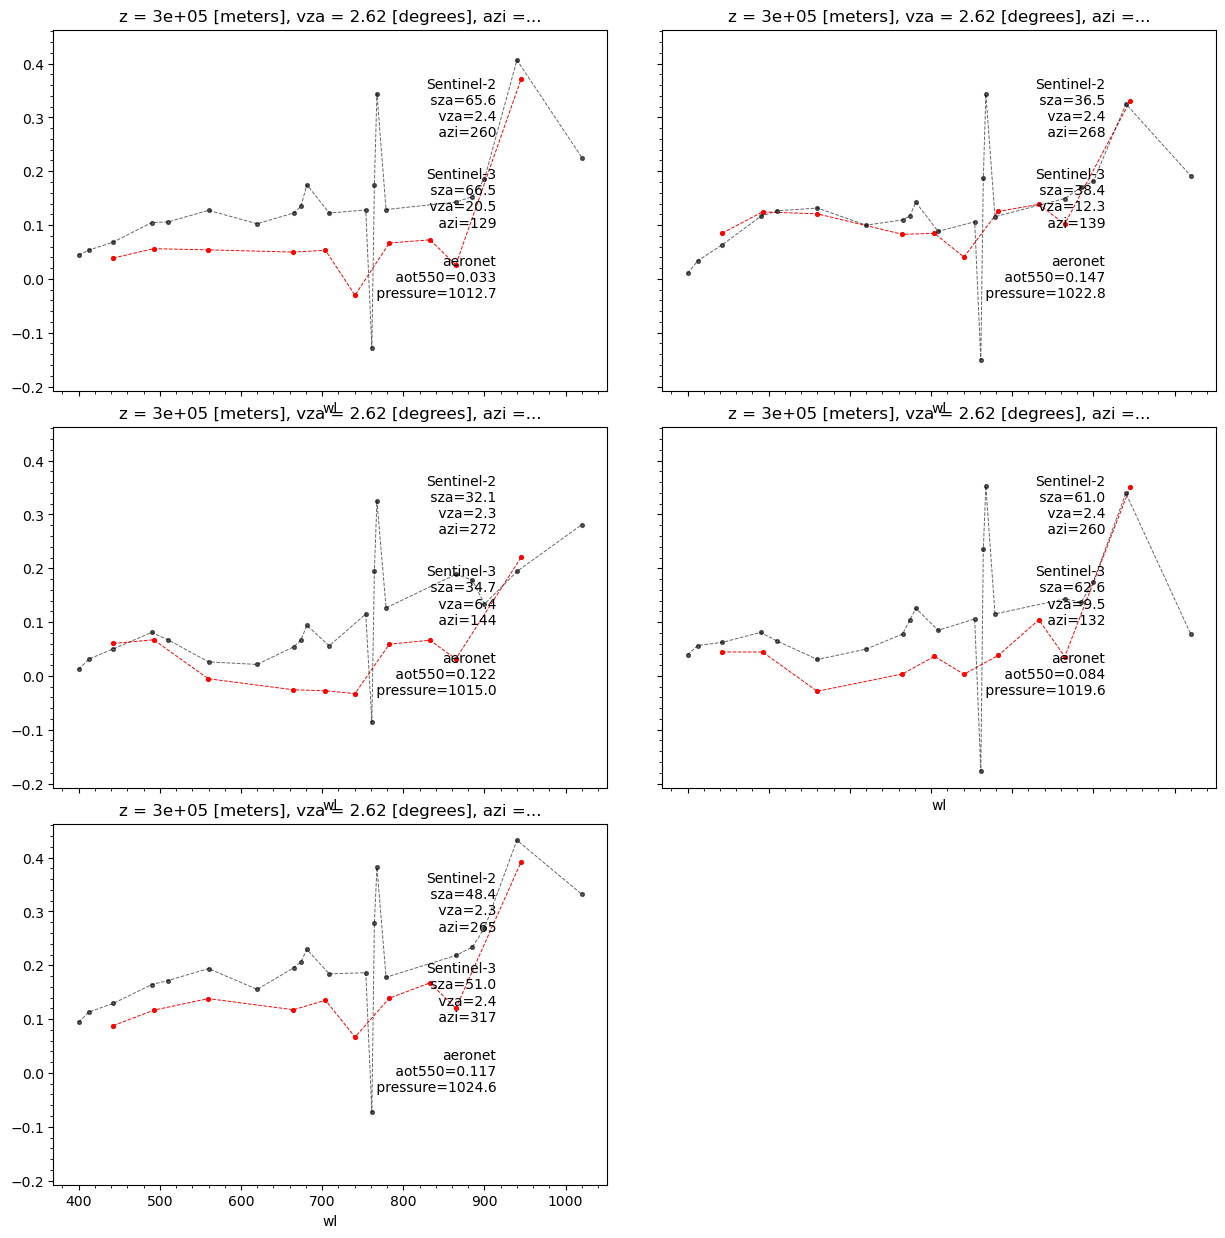

In [83]:

rows=3
cols=2
model='MACL_rh70'
model='COAV_rh0'
to3c=4.5e-3
tno2c=0.5e-6
brdfg_ref=0.001
norm = mpl.colors.Normalize(vmin=0.001,vmax=0.6)
fig, axs = plt.subplots(nrows=rows,ncols=cols, sharex=True,figsize=(cols*7.5, rows*5),sharey=True)
fig.subplots_adjust(hspace=0.1,wspace=0.1)
axs_ = axs.ravel()
[axi.set_axis_off() for axi in axs_]
for ii,(date,ds2) in enumerate(s2_arr.groupby('time')):
    print(date)
    ds2=ds2.sel(wl=slice(350,1050)) #1373.5)
    ds3 = s3_arr.sel(time=date,method='nearest')
    aziRT=(180-ds2.azi.values)%360
    #aziRT=ds2.azi.values
    
    
    
    aeronet_=aeronet.sel(time=date,method='nearest').dropna('wl')
    aot550 = 1.*aeronet_.Aerosol_Optical_Depth.interp(wl=550).values
    pressure = aeronet_['Pressure(hPa)'].values
    
    
    sza=ds2.SZA.values #np.mean([ds2.SZA.values,ds3.SZA.values])
    vza=ds2.VZA.values #np.mean([ds2.VZA.values,ds3.VZA.values])
    M=1./np.cos(np.radians(sza))+1./np.cos(np.radians(vza))
    
    # diffuse light simu
    Rtoa_lut = aero_lut.I.sel(model=model).sel(vza=vza,azi=aziRT,method='nearest').interp(aot_ref=aot550).interp(sza=sza,method='cubic').squeeze()/np.cos(np.radians(sza))
    Rtoa_lut=Rtoa_lut.interp(wl=wl,method='cubic')*pressure/1015

    # sunglint simu
    aot=aero_lut.sel(model=model).aot.interp(aot_ref=aot550).interp(wl=wl,method='cubic')
    Tdir = transmittance_dir(aot,M,rot=rot)
    sunglint_corr = Tdir * sunglint_eps
    sunglint_toa=sunglint_corr *brdfg_ref#( pixel.sel(wl=slice(2150,2350))-Rtoa_lut.sel(wl=slice(2150,2350))).mean(dim='wl')
    #sunglint_toa.Rtoa.plot(x='wl',hue='aot_ref',ax=axs[0])   

    # absorbing gas transmittance
    ot_wv = ot.h2o *tcwv
    ot_o3 = ot.o3 * to3c
    ot_ch4 = ot.ch4 * tch4c
    ot_no2 = ot.no2 * tno2c
    ot_others = (ot.co+ot.co2+ot.n2o+ot.o2+ot.o4)* pressure/1000

    ot_tot = ot_wv+ot_ch4+ot_no2+ot_o3+ot_others 

    Ttot = np.exp(-M*ot_tot)
    Ttot_coarsened = Ttot.coarsen(wl=110,boundary= "trim").mean()
    Tabs = Ttot_coarsened.interp(wl=wl,method='cubic')
    
    # Top-of-atmosphere simu
    Rsim = Tabs*( sunglint_toa+Rtoa_lut)
    Rsim2=Tabs*( sunglint_toa+Rtoa_lut+Rtoa_w.interp(wl=wl,kwargs={"fill_value":0}))
        
    ax=axs_[ii]
    ax.set_axis_on()
    ax.minorticks_on()
   
   
    
    #Rsim.plot(x='wl',color=cmap(norm(aot550)),label=str(aot_ref),ls=':',lw=0.7,ax=ax)
    #Rsim.plot(x='wl',color=cmap(norm(aot550)),label=str(aot_ref),lw=1,ax=axins)
    #Rsim2.plot(x='wl',color=cmap(norm(aot550)),lw=1,ax=ax)
    ((ds2.Rtoa-Rsim2.interp(wl=ds2.wl.values))/ds2.Rtoa).plot(c='red',marker='o',ms=2.7,ls='--',lw=0.7,ax=ax)
    ((ds3.Rtoa-Rsim2.interp(wl=ds3.wl.values))/ds3.Rtoa).plot(c='black',alpha=0.6,marker='o',ms=2.7,ls='--',lw=0.7,ax=ax)
    
  
    
    #ax.set_xlim(385,1100)
    
    s2_text='Sentinel-2\n sza={:.1f}\n vza={:.1f}\n azi={:.0f}\n'.format(ds2.SZA.values,ds2.VZA.values,ds2.azi.values)
    s3_text='Sentinel-3\n sza={:.1f}\n vza={:.1f}\n azi={:.0f}\n'.format(ds3.SZA.values,ds3.VZA.values,ds3.azi.values)
    ax.text(0.8, 0.65,s2_text, verticalalignment='bottom', horizontalalignment='right',
                    transform=ax.transAxes)
    ax.text(0.8, 0.4,s3_text, verticalalignment='bottom', horizontalalignment='right',
                    transform=ax.transAxes)
    ax.text(0.8, 0.25, 'aeronet\n aot550={:.3f}\n pressure={:.1f}'.format(aot550,pressure), verticalalignment='bottom', horizontalalignment='right',
                    transform=ax.transAxes)
    #ax.legend(title='aot(550)')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


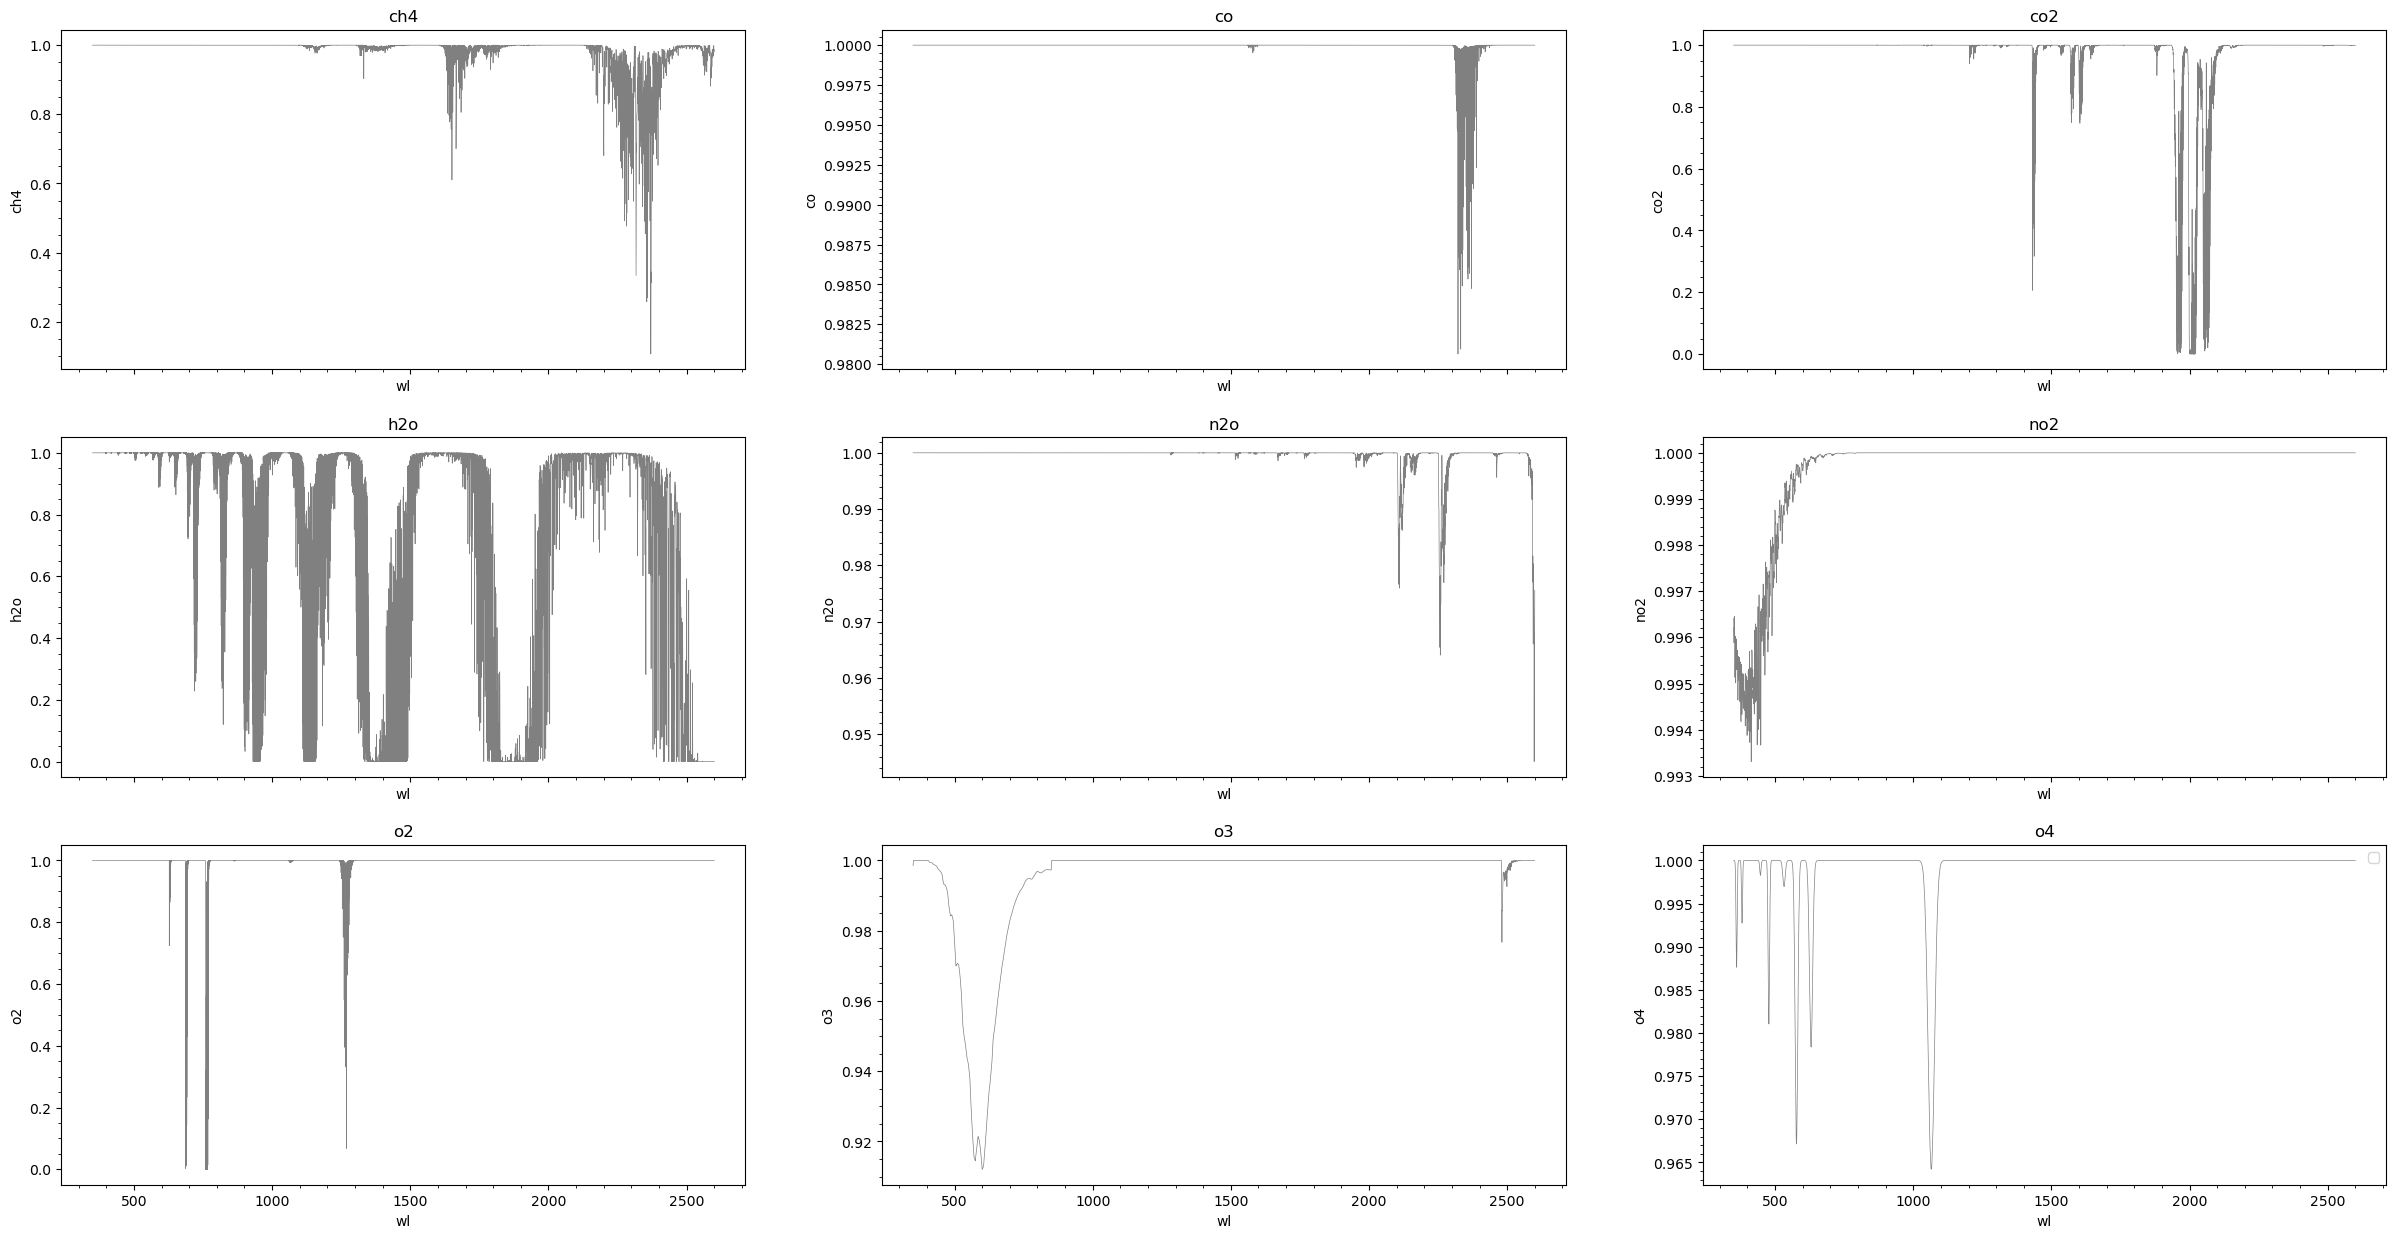

In [149]:
M=1./np.cos(np.radians(sza))+1./np.cos(np.radians(vza))
variable='o4'
variables=['ch4','co','co2','h2o','n2o','no2','o2','o3','o4']
conc={'ch4':tch4c,'co':1,'co2':1,
      'h2o':tcwv,'n2o':1,'no2':tno2c,
      'o2':1,'o3':to3c,'o4':1}

fig,axs = plt.subplots(3,3,figsize=(30,15),sharex=True)
axs=axs.ravel()

for i, variable in enumerate(variables):
    abs_ot = ot[variable]*conc[variable]


    Ttot = (np.exp(-M*abs_ot)) 
    Ttot.plot(ax=axs[i],color='grey',lw=0.5)

    axs[i].minorticks_on()
    axs[i].set_title(variable)
plt.legend()

(350.0, 1000.0)

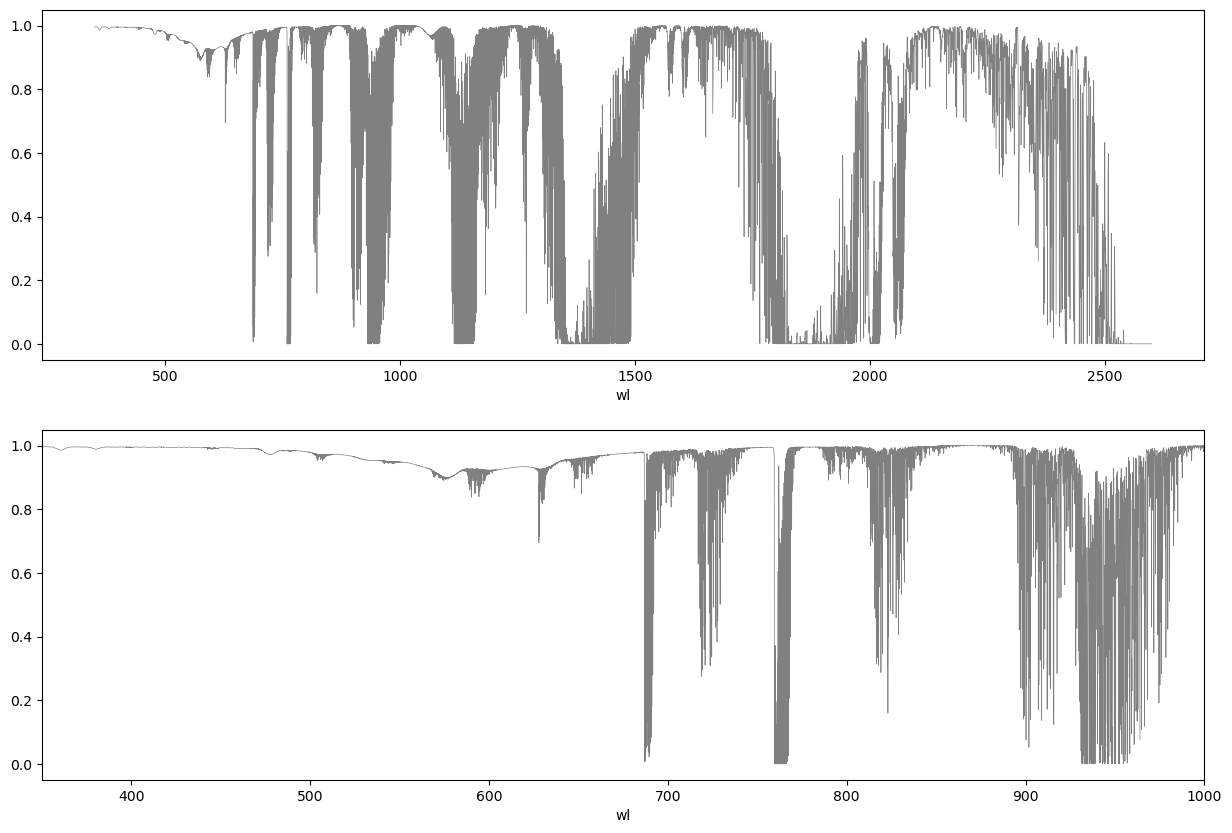

In [247]:


#['ch4','co','co2','h2o','n2o','no2','o2','o3','o4']

ot_wv = ot.h2o *tcwv
ot_o3 = ot.o3 * to3c
ot_ch4 = ot.ch4 * tch4c
ot_no2 = ot.no2 * tno2c
ot_others = (ot.co+ot.co2+ot.n2o+ot.o2+ot.o4)* pressure/1000

ot_tot = ot_wv+ot_ch4+ot_no2+ot_o3+ot_others 

M=2
fig,axs = plt.subplots(nrows=2,figsize=(15,10))
Ttot = np.exp(-M*ot_tot)
Ttot.plot(ax=axs[0],color='grey',lw=0.5)
Ttot.plot(ax=axs[1],color='grey',lw=0.5)
axs[1].set_xlim(350,1000)

In [154]:
aero_lut.model

<xarray.DataArray 'model' (model: 32)>
array(['COAV_rh0', 'DESE_rh0', 'MACL_rh0', 'MAPO_rh0', 'COPO_rh0', 'URBA_rh0',
       'ARCT_rh0', 'ANTA_rh0', 'COAV_rh70', 'DESE_rh70', 'MACL_rh70',
       'MAPO_rh70', 'COPO_rh70', 'URBA_rh70', 'ARCT_rh70', 'ANTA_rh70',
       'COAV_rh90', 'DESE_rh90', 'MACL_rh90', 'MAPO_rh90', 'COPO_rh90',
       'URBA_rh90', 'ARCT_rh90', 'ANTA_rh90', 'COAV_rh99', 'DESE_rh99',
       'MACL_rh99', 'MAPO_rh99', 'COPO_rh99', 'URBA_rh99', 'ARCT_rh99',
       'ANTA_rh99'], dtype=object)
Coordinates:
    z        float32 3e+05
  * model    (model) object 'COAV_rh0' 'DESE_rh0' ... 'ARCT_rh99' 'ANTA_rh99'

## Plot sunglint signal plus diffuse light

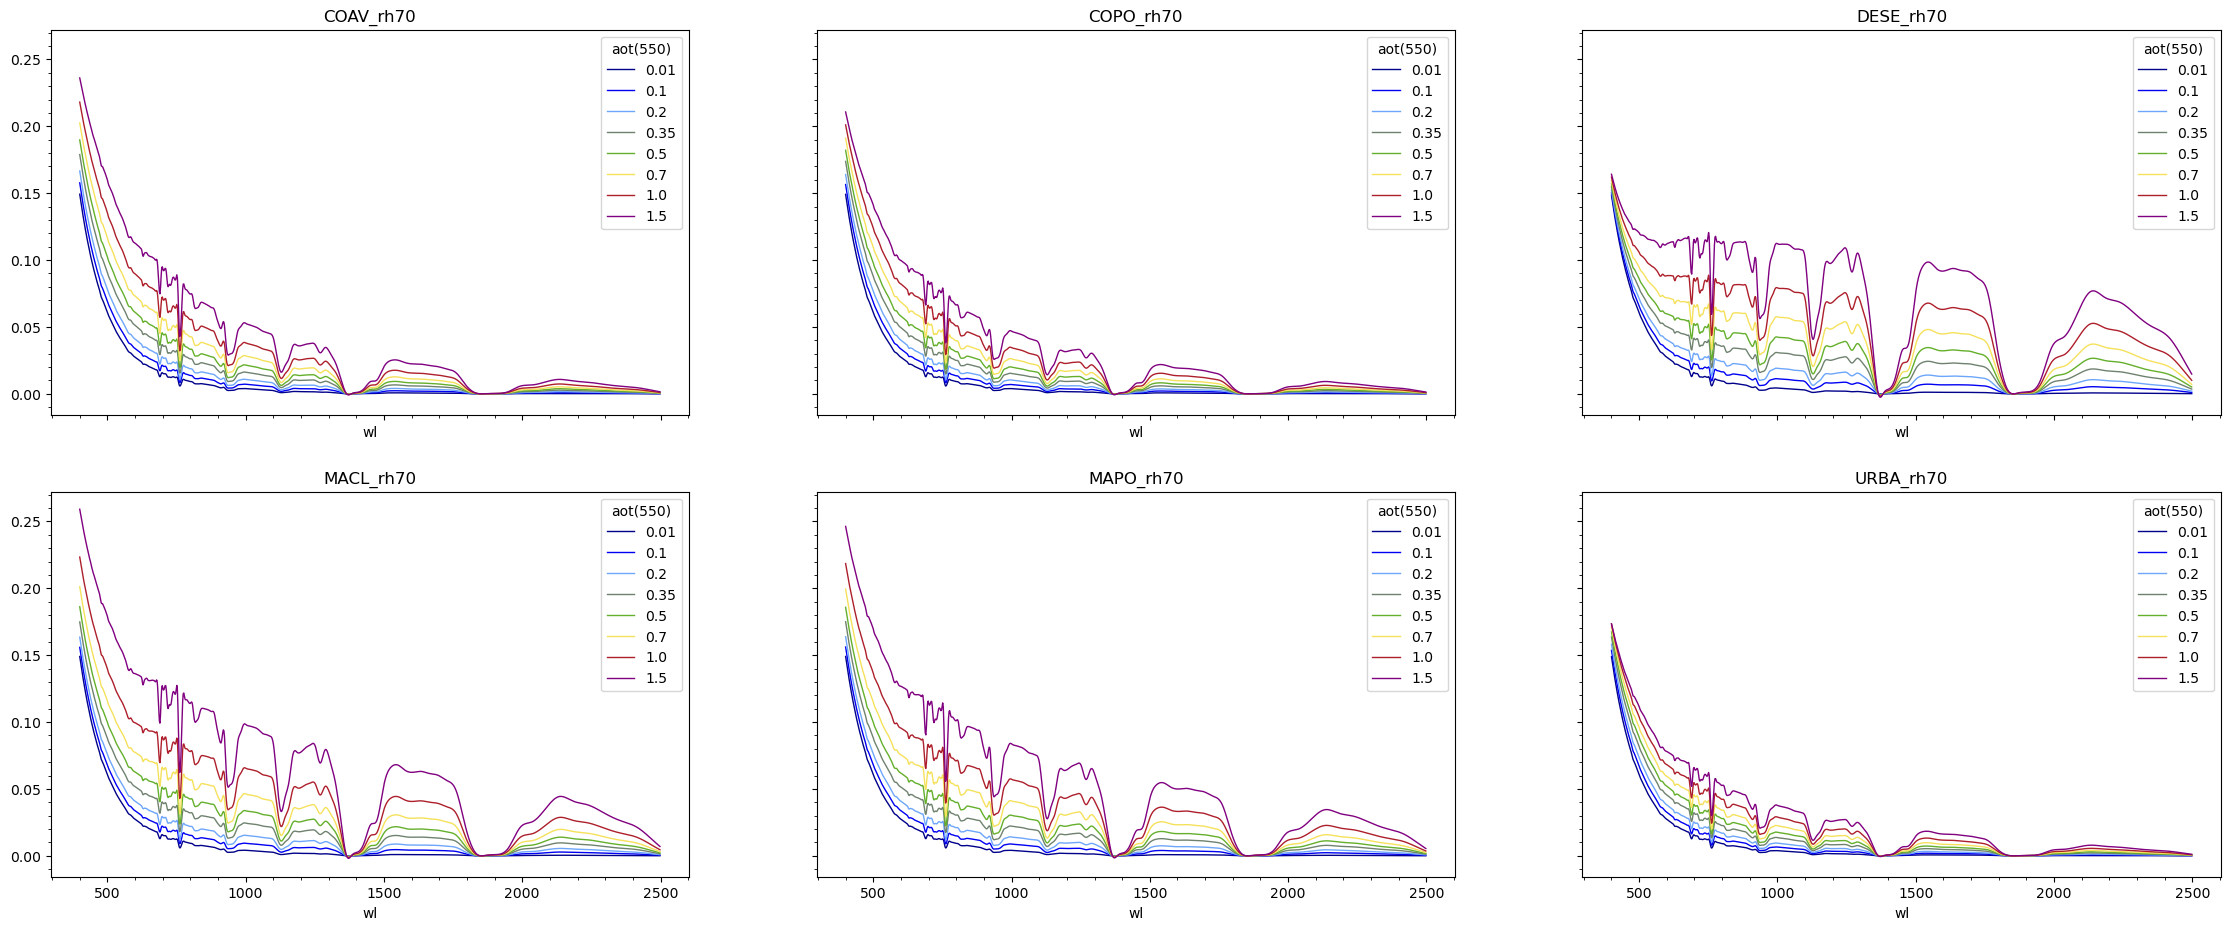

In [156]:
Tabs = Ttot_coarsened.interp(wl=wl,method='cubic')
fig,axs = plt.subplots(2,3,figsize=(28,11),sharey=True,sharex=True)
axs=axs.ravel()
for i_,model_ in  enumerate(models):
    model=model_+rh
    

    Rtoa_lut = aero_lut.I.sel(model=model).sel(sza=sza,vza=vza,azi=azi,method='nearest').squeeze()/np.cos(np.radians(sza))
  
    Rtoa_lut=Rtoa_lut.interp(wl=wl,method='cubic')
    
    aot=aero_lut.sel(model=model).aot.interp(wl=wl,method='cubic')
    Tdir = transmittance_dir(aot,M,rot=rot)
    sunglint_corr = Tdir * sunglint_eps
    sunglint_toa=sunglint_corr *brdfg_ref#( pixel.sel(wl=slice(2150,2350))-Rtoa_lut.sel(wl=slice(2150,2350))).mean(dim='wl')
    #sunglint_toa.Rtoa.plot(x='wl',hue='aot_ref',ax=axs[0])
    
    Rsim = Tabs*( sunglint_toa+Rtoa_lut)
    for aot_ref in Rtoa_lut.aot_ref.values[1:]:
        #Rtoa_lut.sel(aot_ref=aot_ref).plot(x='wl',color=cmap(norm(aot_ref)),ls=':',lw=1,ax=axs[i_])
        Rsim.sel(aot_ref=aot_ref).plot(x='wl',color=cmap(norm(aot_ref)),label=str(aot_ref),lw=1,ax=axs[i_])
    #Rtoa_sim= Rsim.interp(aot_ref=0.4)
    #Rtoa_sim.plot(x='wl',color='black',ls='--',ax=axs[i_])
    axs[i_].set_title(model)
    axs[i_].minorticks_on()
    axs[i_].legend(title='aot(550)')
    

## Transmittance of the downward irradiance

In [148]:
Ttot_Ed = aero_lut.Ed.sel(z=0)/aero_lut.Ed.isel(z=-1)

In [145]:
Ttot_Ed.name='Ttot_Ed'
Ttot_Ed.attrs['description']='Total transmittance of the downward irradiance'
#Ttot_Ed.to_netcdf('/DATA/git/satellite_app/hgrs/data/lut/transmittance_downward_irradiance.nc')

In [146]:
Ttot_Ed

<xarray.DataArray 'Ttot_Ed' (model: 8, aot_ref: 9, wl: 10, sza: 9)>
array([[[[0.7691716 , 0.7663937 , 0.75777894, ..., 0.6318432 ,
          0.5528891 , 0.42872596],
         [0.8540151 , 0.8520681 , 0.84602   , ..., 0.7515756 ,
          0.6853071 , 0.54761934],
         [0.9359    , 0.9349733 , 0.9320677 , ..., 0.8843808 ,
          0.84988487, 0.7560401 ],
         ...,
         [0.9992888 , 0.99927765, 0.99924237, ..., 0.99863   ,
          0.9982743 , 0.9975825 ],
         [0.9997821 , 0.99977857, 0.9997678 , ..., 0.9995754 ,
          0.99945617, 0.99921054],
         [0.9998915 , 0.99988973, 0.9998845 , ..., 0.999794  ,
          0.99974304, 0.99965733]],

        [[0.7663963 , 0.76357895, 0.75484633, ..., 0.6273432 ,
          0.54780555, 0.42459422],
         [0.8515014 , 0.8495171 , 0.8433239 , ..., 0.7466124 ,
          0.6786972 , 0.54001516],
         [0.9338983 , 0.9329247 , 0.9298892 , ..., 0.8796334 ,
          0.84263706, 0.74302185],
...
         [0.9790059 , 0.97832036, 0.97608656, ..., 0.9241132 ,
          0.87327176, 0.73676896],
         [0.9864019 , 0.9860115 , 0.98474264, ..., 0.9556734 ,
          0.92822003, 0.84611243],
         [0.9880114 , 0.98770785, 0.9867248 , ..., 0.964615  ,
          0.9440547 , 0.8827624 ]],

        [[0.6626669 , 0.65832275, 0.6449555 , ..., 0.4763646 ,
          0.40260616, 0.32203507],
         [0.7427768 , 0.73861307, 0.7256726 , ..., 0.54725   ,
          0.46169394, 0.36621818],
         [0.831108  , 0.8274368 , 0.8158718 , ..., 0.6350388 ,
          0.5354121 , 0.41776863],
         ...,
         [0.9682475 , 0.96721417, 0.9638601 , ..., 0.8891902 ,
          0.8193761 , 0.65750235],
         [0.9795564 , 0.9789707 , 0.97707134, ..., 0.9344788 ,
          0.8941592 , 0.78080976],
         [0.982006  , 0.98155105, 0.98007965, ..., 0.9474718 ,
          0.9168651 , 0.8282476 ]]]], dtype=float32)
Coordinates:
  * wl       (wl) float32 350.0 400.0 500.0 600.0 ... 1.6e+03 2.2e+03 2.5e+03
  * aot_ref  (aot_ref) float32 0.001 0.01 0.1 0.2 0.35 0.5 0.7 1.0 1.5
  * sza      (sza) float32 0.0 10.0 20.0 30.0 40.0 50.0 60.0 70.0 80.0
  * model    (model) object 'COAV_rh70' 'DESE_rh70' ... 'ARCT_rh70' 'ANTA_rh70'
Attributes:
    description:  Total transmittance of the downward irradiance

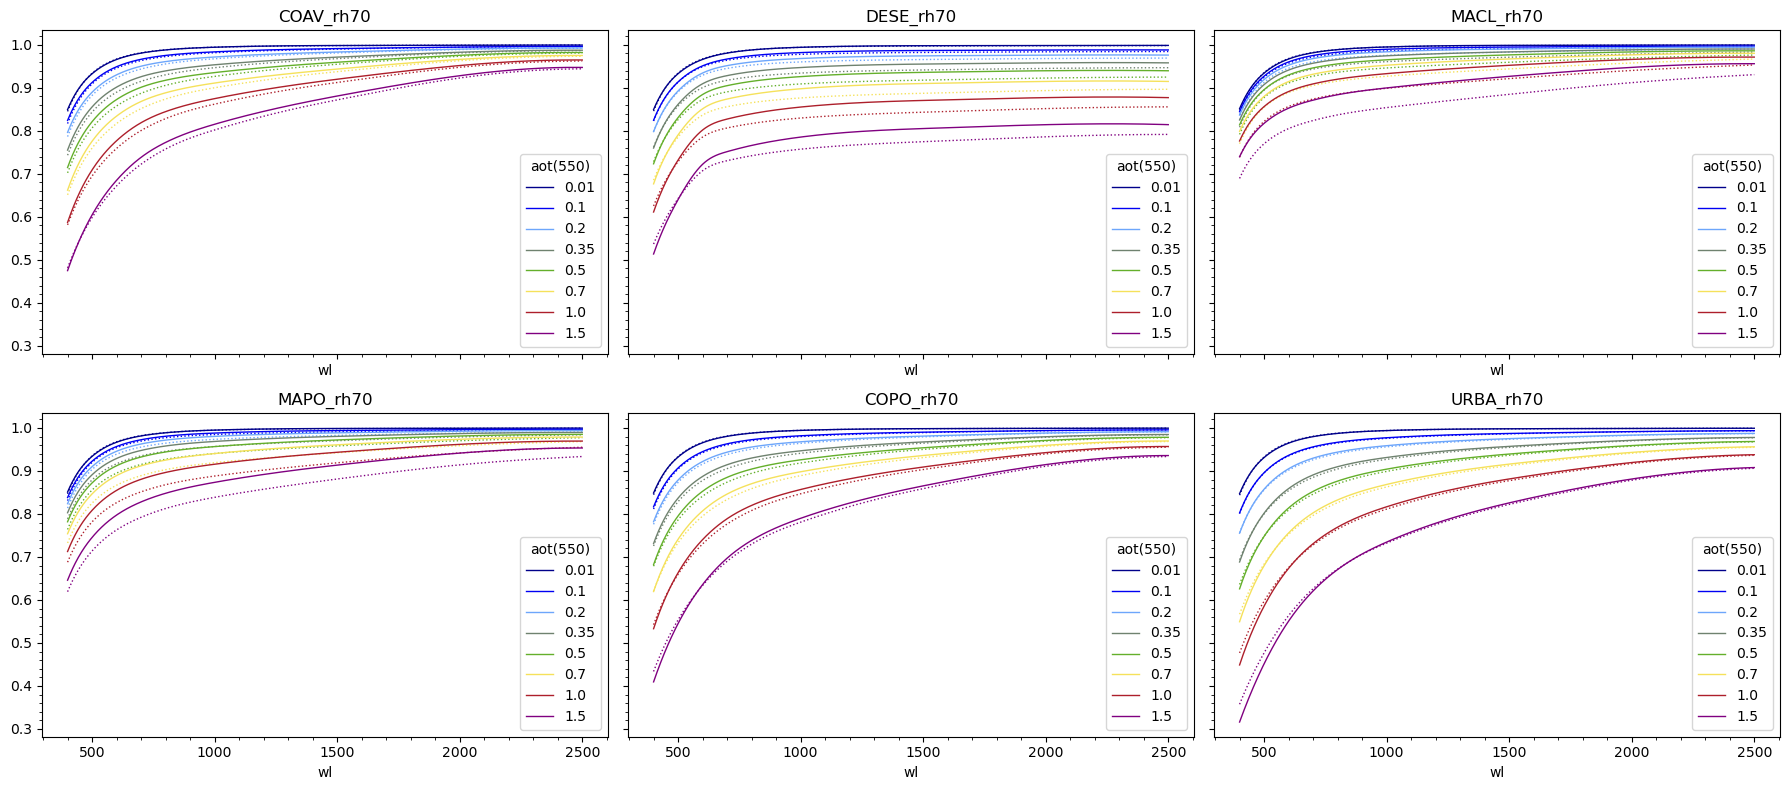

In [107]:


sza = 10
M = 1/np.cos(np.radians(sza))
fig, axs = plt.subplots(2, 3, figsize=(18, 8), sharey=True, sharex=True)
axs = axs.ravel()
for i_, model_ in enumerate(models):
    model = model_ + rh

    Ttot = Ttot_Ed.sel(model=model, sza=sza).interp(wl=wl, method='cubic')

    aot = aero_lut.sel(model=model).aot.interp(wl=wl, method='cubic')
    ssa = aero_lut.sel(model=model).ssa.interp(wl=wl, method='cubic')
    asym = aero_lut.sel(model=model).asym_factor.interp(wl=wl, method='cubic')
    # eq.12b, Tanre et al., 1979 (I do not realy understand the formulation) 
    Tsim = transmittance_dir(aot, M, rot=rot)*(np.exp((0.5*rot+0.5*(1+asym)*ssa*aot)*M)-1)#+ 0.5*transmittance_dir(ssa*aot*(1-asym), M, rot=0.52*rot)#(1-ssa)*aot+
    # personal try:
    Tsim =transmittance_dir(0.5*(1-asym)*ssa*aot+(1-ssa)*aot,M,rot=0.45*rot)
    # eq. 7, Deschamps et al., 1983
    #Tsim = (1+(0.5*rot+0.5*(1-asym)*ssa*aot+(1-ssa)*aot)*M)**-1
    for aot_ref in aero_lut.aot_ref.values[1:]:
        Ttot.sel(aot_ref=aot_ref).plot(x='wl', color=cmap(norm(aot_ref)),label=str(aot_ref),  lw=1, ax=axs[i_])
        Tsim.sel(aot_ref=aot_ref).plot(x='wl', color=cmap(norm(aot_ref)), ls=':', lw=1, ax=axs[i_])
    # Rtoa_sim= Rsim.interp(aot_ref=0.4)
    # Rtoa_sim.plot(x='wl',color='black',ls='--',ax=axs[i_])
    axs[i_].set_title(model)
    axs[i_].minorticks_on()
    axs[i_].legend(title='aot(550)')
plt.tight_layout()

## The socalled "diffuse transmittance" of the downward irradiance

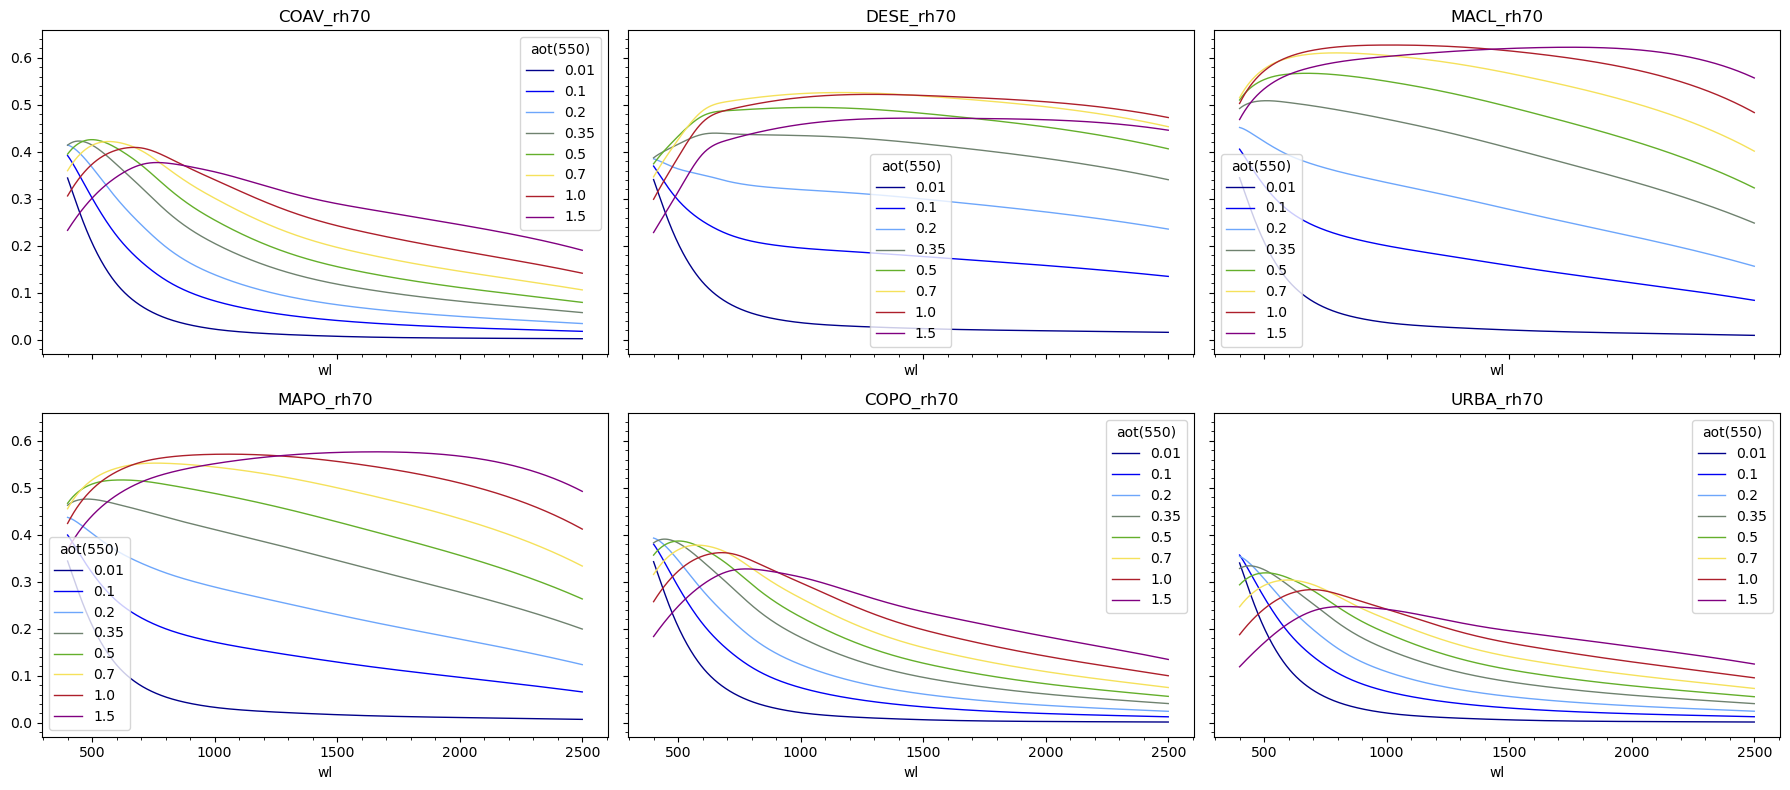

In [112]:


sza = 70
M = 1/np.cos(np.radians(sza))
fig, axs = plt.subplots(2, 3, figsize=(18, 8), sharey=True, sharex=True)
axs = axs.ravel()
for i_, model_ in enumerate(models):
    model = model_ + rh

    Ttot = Ttot_Ed.sel(model=model, sza=sza).interp(wl=wl, method='cubic')

    aot = aero_lut.sel(model=model).aot.interp(wl=wl, method='cubic')
    ssa = aero_lut.sel(model=model).ssa.interp(wl=wl, method='cubic')
    asym = aero_lut.sel(model=model).asym_factor.interp(wl=wl, method='cubic')
    
    Tdir =transmittance_dir(aot, M, rot=rot)#+ 0.5*transmittance_dir(ssa*aot*(1-asym), M, rot=0.52*rot)#(1-ssa)*aot+

    for aot_ref in aero_lut.aot_ref.values[1:]:
        (Ttot -Tdir).sel(aot_ref=aot_ref).plot(x='wl', color=cmap(norm(aot_ref)),label=str(aot_ref),  lw=1, ax=axs[i_])
        #Tdir.sel(aot_ref=aot_ref).plot(x='wl', color=cmap(norm(aot_ref)), ls=':', lw=1, ax=axs[i_])
    # Rtoa_sim= Rsim.interp(aot_ref=0.4)
    # Rtoa_sim.plot(x='wl',color='black',ls='--',ax=axs[i_])
    axs[i_].set_title(model)
    axs[i_].minorticks_on()
    axs[i_].legend(title='aot(550)')
plt.tight_layout()

## Transmittance of the upward "water" radiance

In [115]:
aero_lut = aero_lut.sel(model=aero_lut_bot.model.values)
Iw = aero_lut_bot.I - aero_lut.I
Iw

<xarray.DataArray 'I' (model: 8, wl: 10, aot_ref: 9, z: 2, sza: 9, vza: 61,
                       azi: 73)>
array([[[[[[[1.11645079e+00, 1.11645079e+00, 1.11645079e+00, ...,
             1.11645079e+00, 1.11645079e+00, 1.11645079e+00],
            [1.11647081e+00, 1.11647081e+00, 1.11647081e+00, ...,
             1.11647081e+00, 1.11647081e+00, 1.11647081e+00],
            [1.11645067e+00, 1.11645067e+00, 1.11645067e+00, ...,
             1.11645067e+00, 1.11645067e+00, 1.11645067e+00],
            ...,
            [1.01300395e+00, 1.01300395e+00, 1.01300395e+00, ...,
             1.01300395e+00, 1.01300395e+00, 1.01300395e+00],
            [1.24116504e+00, 1.24116504e+00, 1.24116504e+00, ...,
             1.24116504e+00, 1.24116504e+00, 1.24116504e+00],
            [2.60494184e+00, 2.60494184e+00, 2.60494184e+00, ...,
             2.60494184e+00, 2.60494184e+00, 2.60494184e+00]],

           [[1.09531200e+00, 1.09531200e+00, 1.09531200e+00, ...,
             1.09531200e+00, 1.09531200e+00, 1.09531200e+00],
            [1.09533727e+00, 1.09533739e+00, 1.09533751e+00, ...,
             1.09533751e+00, 1.09533739e+00, 1.09533727e+00],
            [1.09532785e+00, 1.09531796e+00, 1.09531844e+00, ...,
             1.09531844e+00, 1.09531796e+00, 1.09532785e+00],
...
             1.47210002e-01, 1.47210002e-01, 1.47210002e-01],
            [1.32089972e-01, 1.32089972e-01, 1.32090092e-01, ...,
             1.32090092e-01, 1.32089972e-01, 1.32089972e-01],
            [1.13420010e-01, 1.13430023e-01, 1.13420010e-01, ...,
             1.13420010e-01, 1.13430023e-01, 1.13420010e-01]],

           [[1.15688063e-01, 1.15688063e-01, 1.15688063e-01, ...,
             1.15688063e-01, 1.15688063e-01, 1.15688063e-01],
            [1.15938440e-01, 1.15938231e-01, 1.15938574e-01, ...,
             1.15938574e-01, 1.15938231e-01, 1.15938440e-01],
            [1.15859725e-01, 1.15859702e-01, 1.15859568e-01, ...,
             1.15859568e-01, 1.15859702e-01, 1.15859725e-01],
            ...,
            [5.89599609e-02, 5.89599609e-02, 5.89600801e-02, ...,
             5.89600801e-02, 5.89599609e-02, 5.89599609e-02],
            [5.28998375e-02, 5.29000759e-02, 5.28999567e-02, ...,
             5.28999567e-02, 5.29000759e-02, 5.28998375e-02],
            [4.54299450e-02, 4.54301834e-02, 4.54299450e-02, ...,
             4.54299450e-02, 4.54301834e-02, 4.54299450e-02]]]]]]],
      dtype=float32)
Coordinates:
  * wl       (wl) float32 350.0 400.0 500.0 600.0 ... 1.6e+03 2.2e+03 2.5e+03
  * aot_ref  (aot_ref) float32 0.001 0.01 0.1 0.2 0.35 0.5 0.7 1.0 1.5
  * z        (z) float32 0.0 3e+05
  * sza      (sza) float32 0.0 10.0 20.0 30.0 40.0 50.0 60.0 70.0 80.0
  * vza      (vza) float32 0.0 1.14 2.62 4.11 5.61 ... 84.77 86.27 87.76 89.25
  * azi      (azi) float32 0.0 5.0 10.0 15.0 20.0 ... 345.0 350.0 355.0 360.0
  * model    (model) object 'COAV_rh70' 'DESE_rh70' ... 'ARCT_rh70' 'ANTA_rh70'

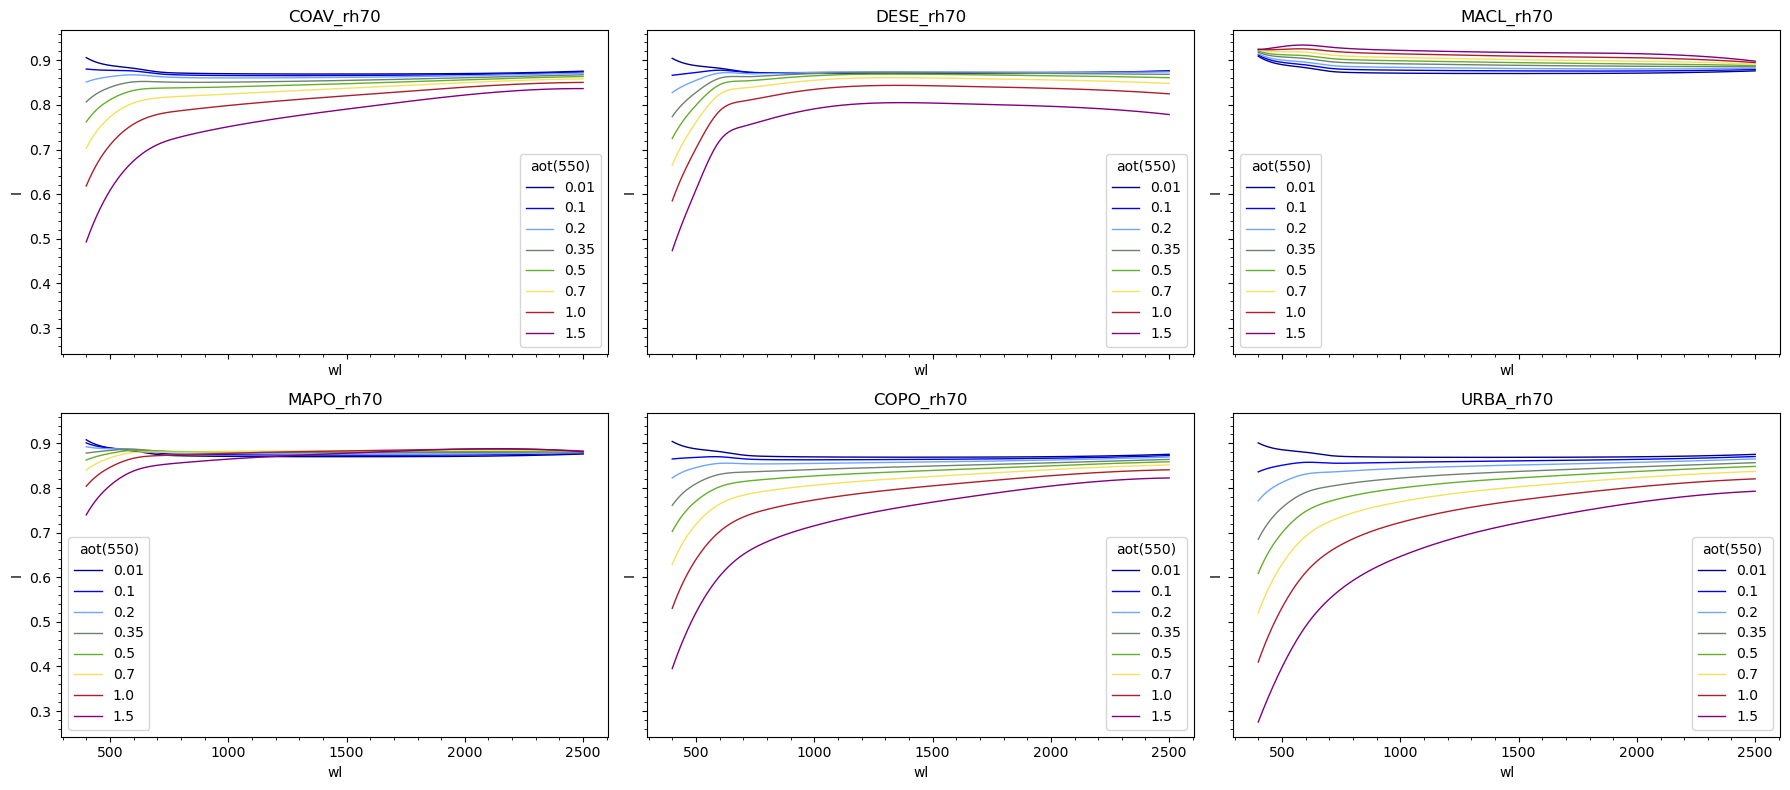

In [134]:
isza = 3
ivza=3
iazi=10
fig, axs = plt.subplots(2, 3, figsize=(18, 8), sharey=True, sharex=True)
axs = axs.ravel()
for i_, model_ in enumerate(models):
    model = model_ + rh

    Iw_=Iw.sel(model=model).isel(vza=ivza, sza=isza, azi=iazi).interp(wl=wl, method='cubic').isel(z=-2)
    for aot_ref in aero_lut.aot_ref.values[1:]:
        Iw_.sel(aot_ref=aot_ref).plot(x='wl', color=cmap(norm(aot_ref)),label=str(aot_ref),  lw=1, ax=axs[i_])
       
    # Rtoa_sim= Rsim.interp(aot_ref=0.4)
    # Rtoa_sim.plot(x='wl',color='black',ls='--',ax=axs[i_])
    axs[i_].set_title(model)
    axs[i_].minorticks_on()
    axs[i_].legend(title='aot(550)')
plt.tight_layout()

In [118]:
Ttot_Lu = Iw.isel(z=-1) / Iw.sel(z=0)

In [141]:
Ttot_Lu.name='Ttot_Lu'
Ttot_Lu.attrs['description']='Total transmittance of the upward "water" radiance'
#Ttot_Lu.to_netcdf('/DATA/git/satellite_app/hgrs/data/lut/transmittance_upward_radiance.nc')

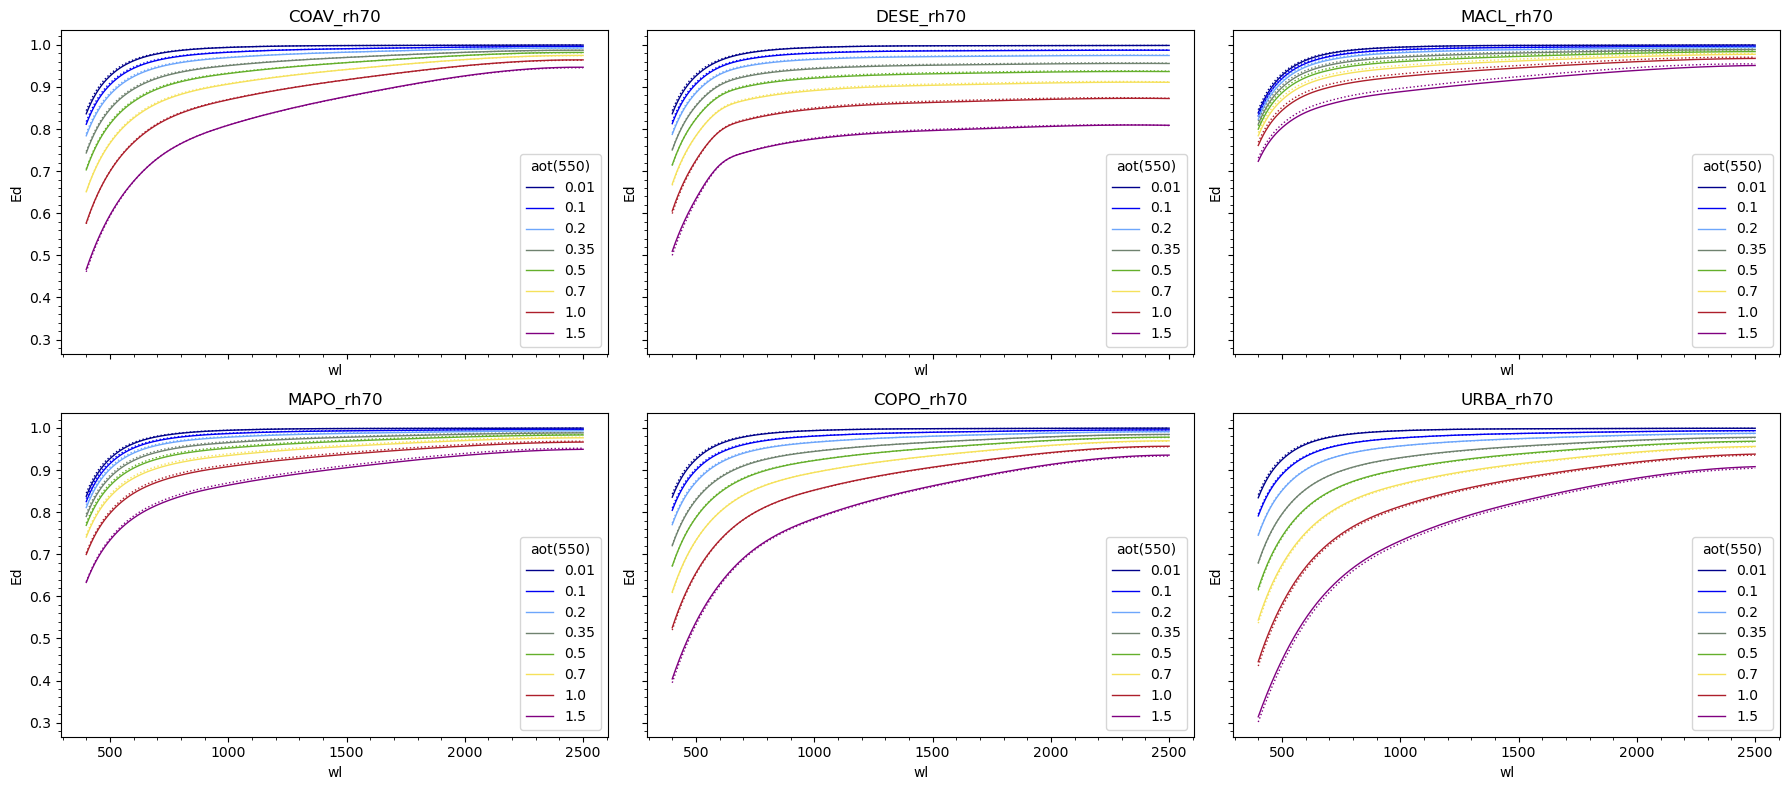

In [163]:
sza = 60

isza = 7
ivza=3
iazi=10
M = np.cos(np.radians(szas[isza]))
fig, axs = plt.subplots(2, 3, figsize=(18, 8), sharey=True, sharex=True)
axs = axs.ravel()
for i_, model_ in enumerate(models):
    model = model_ + rh

    Ttot = Ttot_Lu.sel(model=model).isel(vza=ivza, sza=isza, azi=iazi).interp(wl=wl, method='cubic')
    vza=Ttot.vza.values
    Ttot_Ed_ = Ttot_Ed.sel(model=model).interp(sza=vza).interp(wl=wl, method='cubic')**1.05
    
    aot = aero_lut.sel(model=model).aot.interp(wl=wl, method='cubic')
    ssa = aero_lut.sel(model=model).ssa.interp(wl=wl, method='cubic')
    asym = aero_lut.sel(model=model).asym_factor.interp(wl=wl, method='cubic')
    
    Tsim = transmittance_dir((1-ssa)*aot+ssa*aot*(1-asym), M, rot=0.52*rot)#(1-ssa)*aot+
 # eq.12b, Tanre et al., 1979 (I do not realy understand the formulation) 
    Tsim = transmittance_dir(aot, M, rot=rot)*(np.exp((0.5*rot+0.5*(1+asym)*ssa*aot)*M)-1)#+ 0.5*transmittance_dir(ssa*aot*(1-asym), M, rot=0.52*rot)#(1-ssa)*aot+
    # personal try:
    Tsim =transmittance_dir(0.5*(1-asym)*ssa*aot+(1-ssa)*aot,M,rot=rot)
    # eq. 7, Deschamps et al., 1983
    Tsim = (1+(0.5*rot+0.5*(1-asym)*ssa*aot+(1-ssa)*aot)*M)**-1
    for aot_ref in aero_lut.aot_ref.values[1:]:
        Ttot.sel(aot_ref=aot_ref).plot(x='wl', color=cmap(norm(aot_ref)),label=str(aot_ref),  lw=1, ax=axs[i_])
        Ttot_Ed_.sel(aot_ref=aot_ref).plot(x='wl', color=cmap(norm(aot_ref)), ls=':', lw=1, ax=axs[i_])
    # Rtoa_sim= Rsim.interp(aot_ref=0.4)
    # Rtoa_sim.plot(x='wl',color='black',ls='--',ax=axs[i_])
    axs[i_].set_title(model)
    axs[i_].minorticks_on()
    axs[i_].legend(title='aot(550)')
plt.tight_layout()

## Total up and downward transmitance

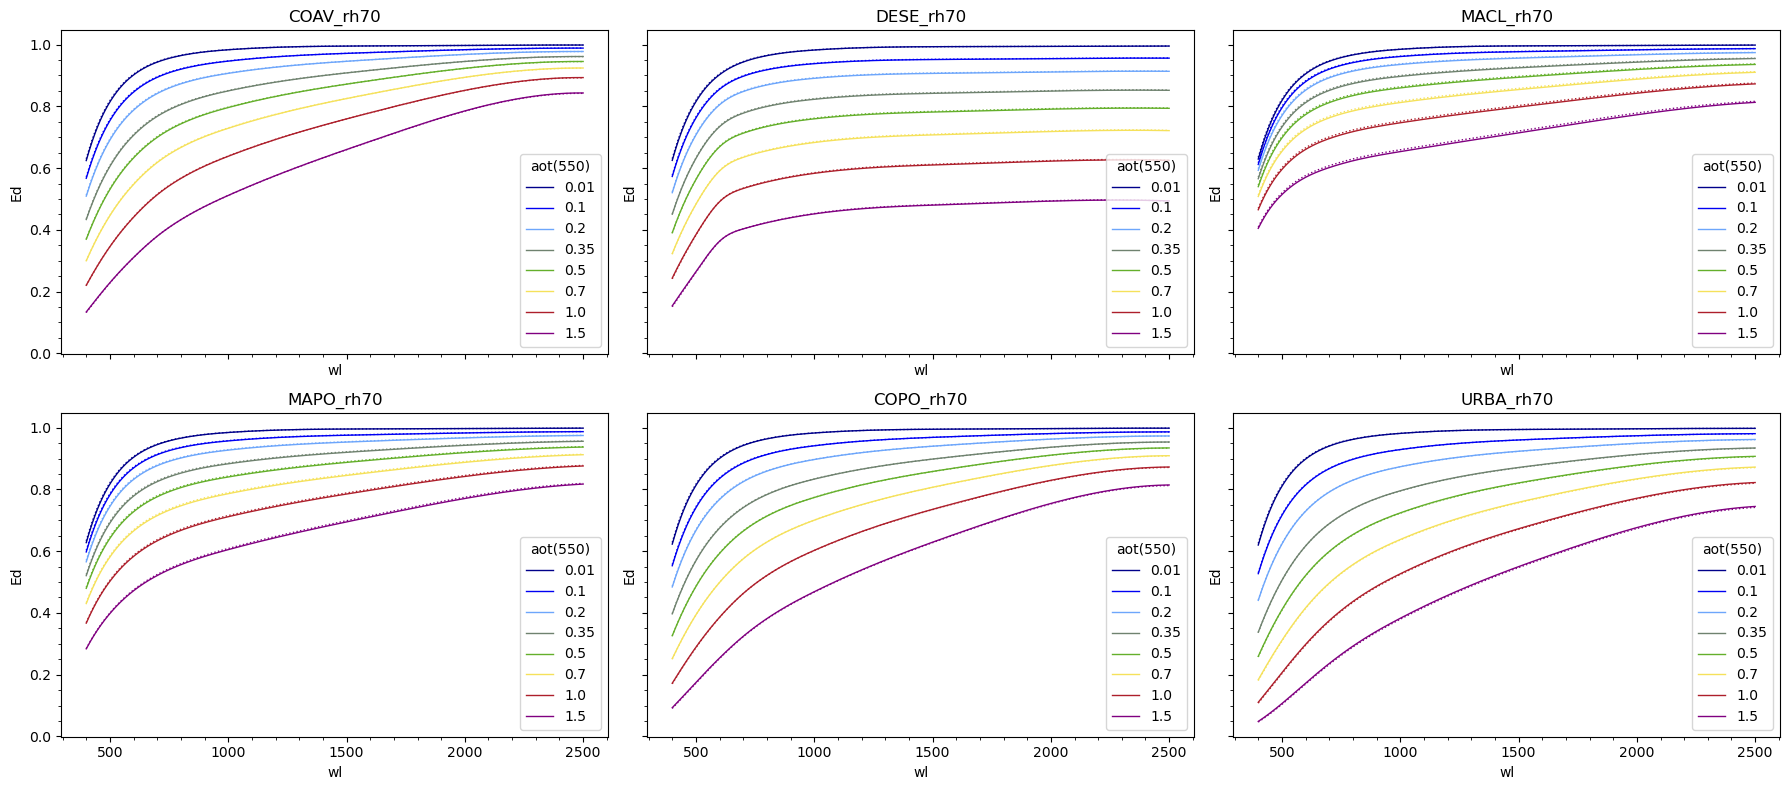

In [164]:

isza = 7
ivza=3
iazi=10
M = np.cos(np.radians(szas[isza]))
fig, axs = plt.subplots(2, 3, figsize=(18, 8), sharey=True, sharex=True)
axs = axs.ravel()
for i_, model_ in enumerate(models):
    model = model_ + rh
    Ttot_Ed_ = Ttot_Ed.sel(model=model, sza=sza).interp(wl=wl, method='cubic')
    Ttot_Lu_ = Ttot_Lu.sel(model=model).isel(vza=ivza, sza=isza, azi=iazi).interp(wl=wl, method='cubic')
    vza=Ttot.vza.values
    Ttot_Lu_sim = Ttot_Ed.sel(model=model).interp(sza=vza).interp(wl=wl, method='cubic')**1.05
    Ttot = Ttot_Ed_ *Ttot_Lu_
    Ttot_sim = Ttot_Ed_ *Ttot_Lu_sim
    aot = aero_lut.sel(model=model).aot.interp(wl=wl, method='cubic')
    ssa = aero_lut.sel(model=model).ssa.interp(wl=wl, method='cubic')
    asym = aero_lut.sel(model=model).asym_factor.interp(wl=wl, method='cubic')
    
    Tsim = transmittance_dir((1-ssa)*aot+ssa*aot*(1-asym), M, rot=0.52*rot)#(1-ssa)*aot+
 # eq.12b, Tanre et al., 1979 (I do not realy understand the formulation) 
    Tsim = transmittance_dir(aot, M, rot=rot)*(np.exp((0.5*rot+0.5*(1+asym)*ssa*aot)*M)-1)#+ 0.5*transmittance_dir(ssa*aot*(1-asym), M, rot=0.52*rot)#(1-ssa)*aot+
    # personal try:
    Tsim =transmittance_dir(0.5*(1-asym)*ssa*aot+(1-ssa)*aot,M,rot=rot)
    # eq. 7, Deschamps et al., 1983
    Tsim = (1+(0.5*rot+0.5*(1-asym)*ssa*aot+(1-ssa)*aot)*M)**-1
    for aot_ref in aero_lut.aot_ref.values[1:]:
        Ttot.sel(aot_ref=aot_ref).plot(x='wl', color=cmap(norm(aot_ref)),label=str(aot_ref),  lw=1, ax=axs[i_])
        Ttot_sim.sel(aot_ref=aot_ref).plot(x='wl', color=cmap(norm(aot_ref)), ls=':', lw=1, ax=axs[i_])
    # Rtoa_sim= Rsim.interp(aot_ref=0.4)
    # Rtoa_sim.plot(x='wl',color='black',ls='--',ax=axs[i_])
    axs[i_].set_title(model)
    axs[i_].minorticks_on()
    axs[i_].legend(title='aot(550)')
plt.tight_layout()

In [63]:
aero_lut['I'].isel(z=-2)

<xarray.DataArray 'I' (model: 32, wl: 10, aot_ref: 9, sza: 9, vza: 61, azi: 73)>
[115421760 values with dtype=float32]
Coordinates:
  * wl       (wl) float32 350.0 400.0 500.0 600.0 ... 1.6e+03 2.2e+03 2.5e+03
  * aot_ref  (aot_ref) float32 0.001 0.01 0.1 0.2 0.35 0.5 0.7 1.0 1.5
    z        float32 0.0
  * sza      (sza) float32 0.0 10.0 20.0 30.0 40.0 50.0 60.0 70.0 80.0
  * vza      (vza) float32 0.0 1.14 2.62 4.11 5.61 ... 84.77 86.27 87.76 89.25
  * azi      (azi) float32 0.0 5.0 10.0 15.0 20.0 ... 345.0 350.0 355.0 360.0
  * model    (model) object 'COAV_rh0' 'DESE_rh0' ... 'ARCT_rh99' 'ANTA_rh99'
Attributes:
    unit:         -
    long_name:    normalized_radiance
    description:  I stokes parameter, can be scaled into radiance unit by mul...

In [58]:
Trans = aero_lut['I'].isel(z=-1) / aero_lut['I'].isel(z=-2)
ivza = 8
szas = Trans.sza.values
vzas = Trans.vza.values

muv = np.cos(np.radians(Trans.vza))

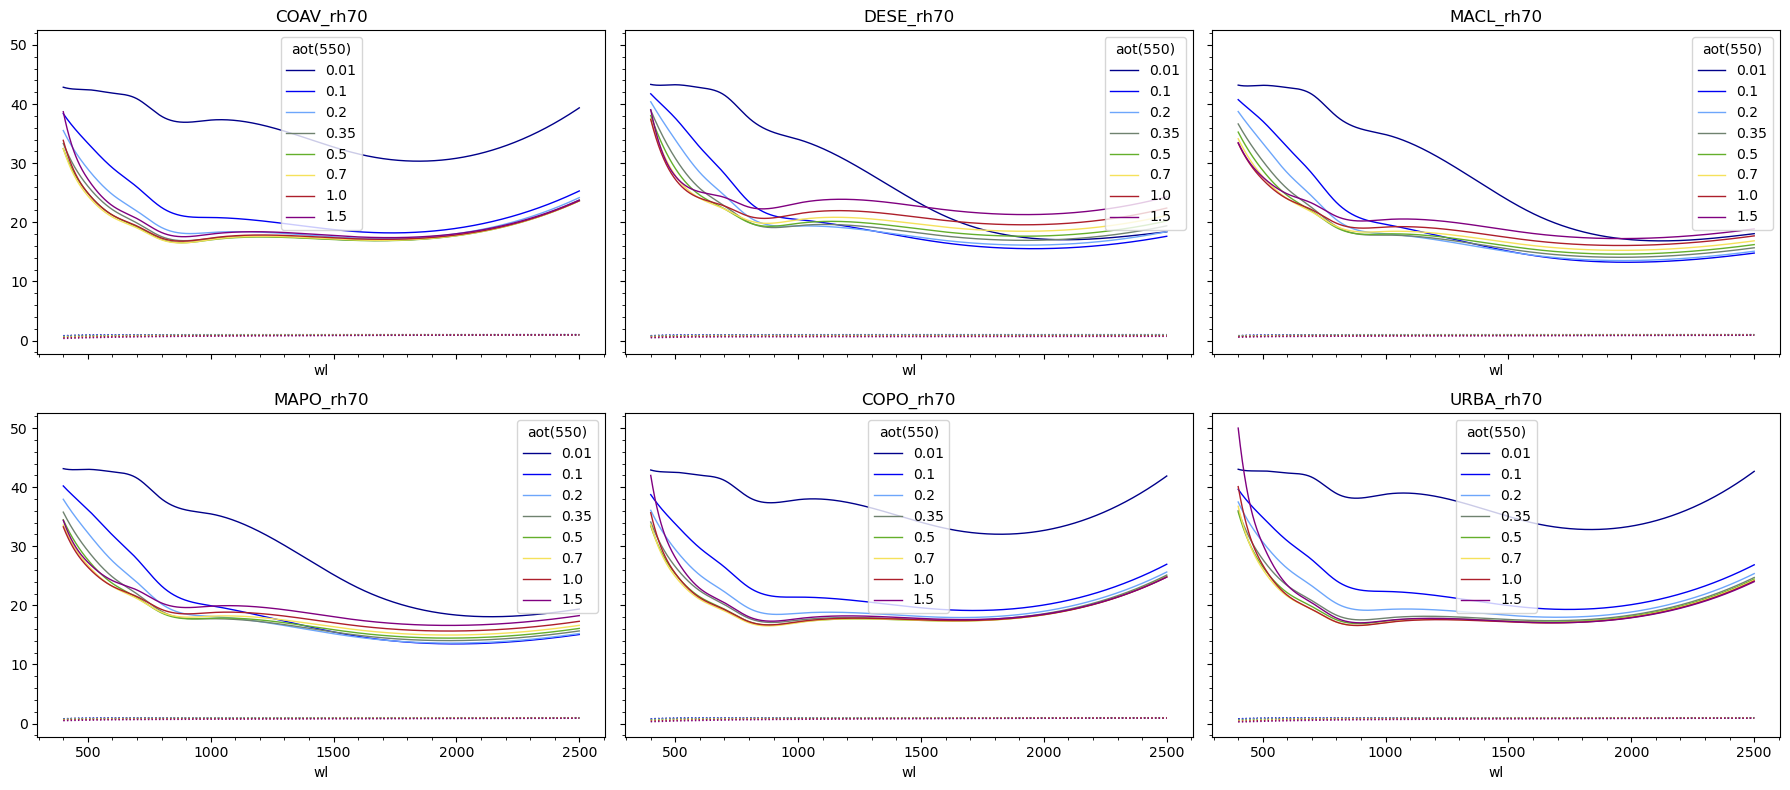

In [61]:
# ---------------------------------------
# transmittance of upward radiance
# ---------------------------------------

isza = 6
ivza=3
iazi=10
M = np.cos(np.radians(sza))
fig, axs = plt.subplots(2, 3, figsize=(18, 8), sharey=True, sharex=True)
axs = axs.ravel()
for i_, model_ in enumerate(models):
    model = model_ + rh

    T_Lu = Trans.sel(model=model).isel(vza=ivza, sza=isza, azi=iazi).interp(wl=wl, method='cubic')
    vza=T_Lu.vza.values
    M = np.cos(np.radians(vza))
    aot = aero_lut.sel(model=model).aot.interp(wl=wl, method='cubic')
    ssa = aero_lut.sel(model=model).ssa.interp(wl=wl, method='cubic')
    asym = aero_lut.sel(model=model).asym_factor.interp(wl=wl, method='cubic')
    
    Tsim = transmittance_dir((1-ssa)*aot+ssa*aot*(1-asym), M, rot=0.52*rot)#(1-ssa)*aot+

    for aot_ref in aero_lut.aot_ref.values[1:]:
        T_Lu.sel(aot_ref=aot_ref).plot(x='wl', color=cmap(norm(aot_ref)),label=str(aot_ref),  lw=1, ax=axs[i_])
        Tsim.sel(aot_ref=aot_ref).plot(x='wl', color=cmap(norm(aot_ref)), ls=':', lw=1, ax=axs[i_])
    # Rtoa_sim= Rsim.interp(aot_ref=0.4)
    # Rtoa_sim.plot(x='wl',color='black',ls='--',ax=axs[i_])
    axs[i_].set_title(model)
    axs[i_].minorticks_on()
    axs[i_].legend(title='aot(550)')
plt.tight_layout()



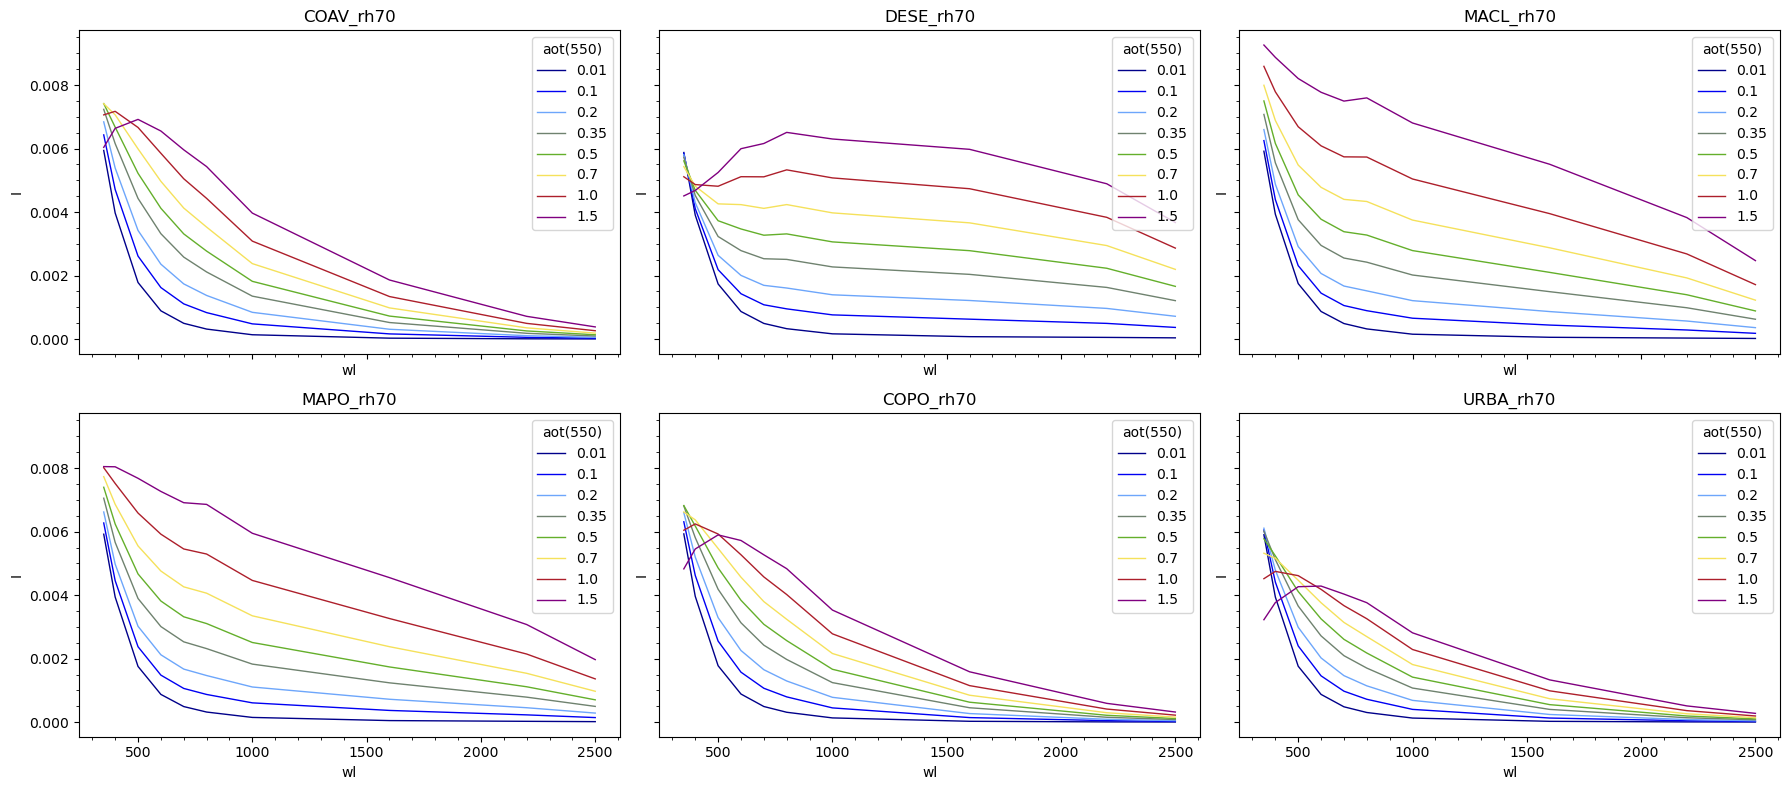

In [69]:

isza = 6
ivza=3
iazi=10
M = np.cos(np.radians(sza))
fig, axs = plt.subplots(2, 3, figsize=(18, 8), sharey=True, sharex=True)
axs = axs.ravel()
for i_, model_ in enumerate(models):
    model = model_ + rh

    Lu = aero_lut.I.sel(model=model).isel(vza=ivza, sza=isza, azi=iazi).isel(z=0)
    sza=Lu.sza.values
    Lu =(Lu/np.cos(np.radians(sza)))#.interp(wl=wl, method='cubic')
    #M = np.cos(np.radians(vza))
    #aot = aero_lut.sel(model=model).aot.interp(wl=wl, method='cubic')
    #ssa = aero_lut.sel(model=model).ssa.interp(wl=wl, method='cubic')
    #asym = aero_lut.sel(model=model).asym_factor.interp(wl=wl, method='cubic')
    
    #Tsim = transmittance_dir((1-ssa)*aot+ssa*aot*(1-asym), M, rot=0.52*rot)#(1-ssa)*aot+

    for aot_ref in aero_lut.aot_ref.values[1:]:
        Lu.sel(aot_ref=aot_ref).plot(x='wl', color=cmap(norm(aot_ref)),label=str(aot_ref),  lw=1, ax=axs[i_])
        #Tsim.sel(aot_ref=aot_ref).plot(x='wl', color=cmap(norm(aot_ref)), ls=':', lw=1, ax=axs[i_])
    # Rtoa_sim= Rsim.interp(aot_ref=0.4)
    # Rtoa_sim.plot(x='wl',color='black',ls='--',ax=axs[i_])
    axs[i_].set_title(model)
    axs[i_].minorticks_on()
    axs[i_].legend(title='aot(550)')
plt.tight_layout()



In [48]:
cams = xr.open_dataset('/DATA/projet/magellium/acix-iii/cams/PRS_L1_STD_OFFL_20220930074620_20220930074624_0001_cams.nc')

In [49]:
aod = cams[['aod355', 'aod380', 'aod400', 'aod440', 'aod469', 'aod500', 'aod550', 'aod645', 'aod670',
 'aod800', 'aod865','aod1020', 'aod1064', 'aod1240', 'aod1640', 'aod2130']].to_pandas()
aod.index=aod.index.str.replace('aod','').astype(int)
cams_aod=aod.to_xarray().rename({'index':'wl'})


In [54]:
rh='_rh70'
models = ['ANTA'+rh,'ARCT'+rh,'COAV'+rh, 'COPO'+rh, 'DESE'+rh, 'MACL'+rh, 'MAPO'+rh, 'URBA'+rh]


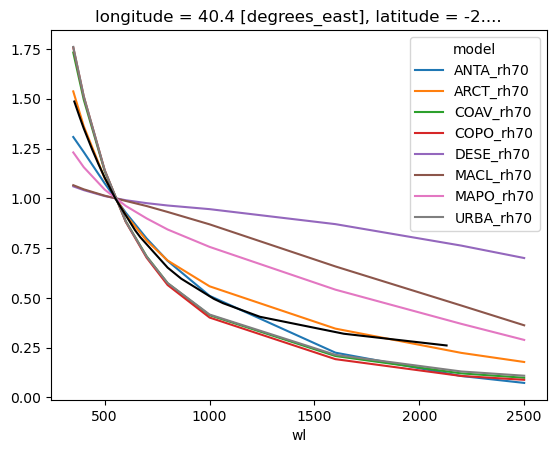

In [55]:
aero_lut.aot.sel(model=models,aot_ref=1).plot(hue='model')
(cams_aod/cams.aod550).plot(color='black')

In [1]:
lut_aod=aero_lut.aot.sel(model=models,aot_ref=1).interp(wl=cams_aod.wl)
rank = np.abs((cams_aod/cams.aod550)-lut_aod).sum('wl') 
plt.figure(figsize=(35,4))
plt.bar(x=rank.model, height=rank.values)

NameError: name 'aero_lut' is not defined

In [10]:
aero_lut

<xarray.Dataset>
Dimensions:            (wl: 10, model: 32, aot_ref: 9, z: 2, sza: 9, vza: 61,
                        azi: 73)
Coordinates:
  * wl                 (wl) float32 350.0 400.0 500.0 ... 2.2e+03 2.5e+03
  * aot_ref            (aot_ref) float32 0.001 0.01 0.1 0.2 0.35 0.5 0.7 1.0 1.5
  * z                  (z) float32 0.0 3e+05
  * sza                (sza) float32 0.0 10.0 20.0 30.0 40.0 50.0 60.0 70.0 80.0
  * vza                (vza) float32 0.0 1.14 2.62 4.11 ... 86.27 87.76 89.25
  * azi                (azi) float32 0.0 5.0 10.0 15.0 ... 350.0 355.0 360.0
  * model              (model) object 'COAV_rh0' 'DESE_rh0' ... 'ANTA_rh99'
Data variables: (12/20)
    wl_ref             (model, wl, aot_ref) float32 ...
    Cext_ref           (model, wl, aot_ref) float32 ...
    ssa_ref            (model, wl, aot_ref) float32 ...
    aot                (model, wl, aot_ref) float32 ...
    Cext               (model, wl, aot_ref) float32 ...
    ssa                (model, wl, aot_ref) float32 ...
    ...                 ...
    Eddir              (model, aot_ref, wl, z, sza) float32 ...
    Eudir              (model, aot_ref, wl, z, sza) float32 ...
    Eodir              (model, aot_ref, wl, z, sza) float32 ...
    I                  (model, wl, aot_ref, z, sza, vza, azi) float32 ...
    Q                  (model, wl, aot_ref, z, sza, vza, azi) float32 ...
    U                  (model, wl, aot_ref, z, sza, vza, azi) float32 ...

In [21]:
aot=aero_lut.sel(model=model).aot.interp(wl=wl,method='cubic')
Tdir = transmittance_dir(aot,M,rot=rot)
Tdir

<xarray.DataArray (wl: 1000, aot_ref: 9)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * wl       (wl) float64 400.0 402.1 404.2 ... 2.496e+03 2.498e+03 2.5e+03
  * aot_ref  (aot_ref) float32 0.001 0.01 0.1 0.2 0.35 0.5 0.7 1.0 1.5
    model    <U9 'URBA_rh70'

## check NDWI and similar indices

In [ ]:
fig,axs = plt.subplots(2,3,figsize=(28,11),sharey=True,sharex=True)
axs=axs.ravel()
wl=[550,865,1600,2200]
for i_,model_ in  enumerate(models):
    model=model_+rh
    

    Rtoa_lut = aero_lut.I.sel(model=model).drop_isel(aot_ref=[0,4,6,8]).sel(sza=sza,vza=vza,azi=azi,method='nearest').squeeze()/np.cos(np.radians(sza))
  
    Rtoa_lut=Rtoa_lut.interp(wl=wl,method='cubic')
    
    aot=aero_lut.sel(model=model).aot.interp(wl=wl,method='cubic')
    Tdir = transmittance_dir(aot,M,rot=rot)
    sunglint_corr = Tdir * sunglint_eps
    sunglint_toa=sunglint_corr *brdfg_ref#( pixel.sel(wl=slice(2150,2350))-Rtoa_lut.sel(wl=slice(2150,2350))).mean(dim='wl')
    #sunglint_toa.Rtoa.plot(x='wl',hue='aot_ref',ax=axs[0])
    
    Rsim = ( sunglint_toa+Rtoa_lut)
    
    
    for aot_ref in Rtoa_lut.aot_ref.values[1:]:
        Rtoa_lut.sel(aot_ref=aot_ref).plot(x='wl',color=cmap(norm(aot_ref)),ls=':',lw=1,ax=axs[i_])
        Rsim.sel(aot_ref=aot_ref).plot(x='wl',color=cmap(norm(aot_ref)),label=str(aot_ref),lw=1,ax=axs[i_])
    #Rtoa_sim= Rsim.interp(aot_ref=0.4)
    #Rtoa_sim.plot(x='wl',color='black',ls='--',ax=axs[i_])
    axs[i_].set_title(model)
    axs[i_].minorticks_on()
    axs[i_].legend(title='aot(550)')

In [29]:
Rtoa_lut = aero_lut.I.isel(sza=slice(1,9)).sel(vza=vza,azi=azi,method='nearest').squeeze()/np.cos(np.radians(sza))  
Rtoa_lut.isel(wl=2)#.interp(wl=wl,method='quadratic')

<xarray.DataArray 'I' (model: 32, aot_ref: 9, sza: 8)>
array([[[0.07594077, 0.07266093, 0.06744726, ..., 0.05016746,
         0.04546707, 0.03575967],
        [0.07734447, 0.07382196, 0.06869928, ..., 0.0509879 ,
         0.04614002, 0.03603316],
        [0.09055009, 0.08498763, 0.07841007, ..., 0.05881121,
         0.05238169, 0.03857896],
        ...,
        [0.14903834, 0.13966814, 0.12883326, ..., 0.09614938,
         0.07699592, 0.04598284],
        [0.16788973, 0.15865007, 0.14835562, ..., 0.10723046,
         0.08287992, 0.04750508],
        [0.19151108, 0.18248028, 0.17072377, ..., 0.11886634,
         0.08856745, 0.04904794]],

       [[0.07594572, 0.07262751, 0.06740706, ..., 0.05013091,
         0.04543509, 0.03574375],
        [0.0773617 , 0.0734631 , 0.06826131, ..., 0.05060908,
         0.04581   , 0.03586581],
        [0.09030925, 0.0814843 , 0.07418773, ..., 0.05521847,
         0.04937129, 0.03710438],
...
        [0.15201207, 0.13506919, 0.11951278, ..., 0.09049644,
         0.07542892, 0.04629758],
        [0.16993402, 0.15485525, 0.1413247 , ..., 0.10622582,
         0.08527325, 0.049338  ],
        [0.19761908, 0.18635081, 0.17300564, ..., 0.12953256,
         0.09885106, 0.05372769]],

       [[0.07600787, 0.07266915, 0.06743173, ..., 0.05012881,
         0.04543705, 0.03574962],
        [0.07796832, 0.07386712, 0.06850517, ..., 0.05058205,
         0.04582436, 0.0359192 ],
        [0.09606636, 0.08537325, 0.07660835, ..., 0.05513805,
         0.04962676, 0.03758959],
        ...,
        [0.168891  , 0.14306481, 0.12382989, ..., 0.0865083 ,
         0.07286366, 0.04594055],
        [0.19106854, 0.1657345 , 0.14737396, ..., 0.10211496,
         0.08301058, 0.04921125],
        [0.22350791, 0.20124158, 0.18203384, ..., 0.1268211 ,
         0.09796337, 0.05417179]]], dtype=float32)
Coordinates:
    wl       float32 500.0
  * aot_ref  (aot_ref) float32 0.001 0.01 0.1 0.2 0.35 0.5 0.7 1.0 1.5
    z        float32 3e+05
    vza      float32 10.09
    azi      float32 90.0
  * sza      (sza) float32 10.0 20.0 30.0 40.0 50.0 60.0 70.0 80.0
  * model    (model) object 'COAV_rh0' 'DESE_rh0' ... 'ARCT_rh99' 'ANTA_rh99'

In [18]:
aero_lut.I.drop_isel(aot_ref=[0,4,6,8]).sel(model=model)

SyntaxError: positional argument follows keyword argument (1658192731.py, line 1)